In [29]:
import importlib
import pacesyncedhelper

importlib.reload(pacesyncedhelper)

from pacesyncedhelper import analyse_pace_synchronisation

10299
100
100


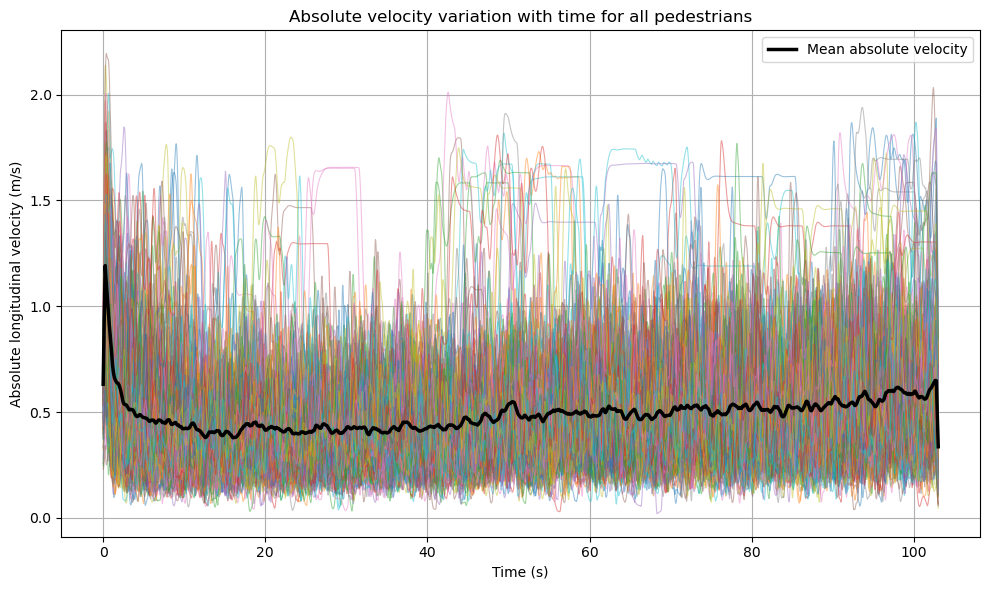

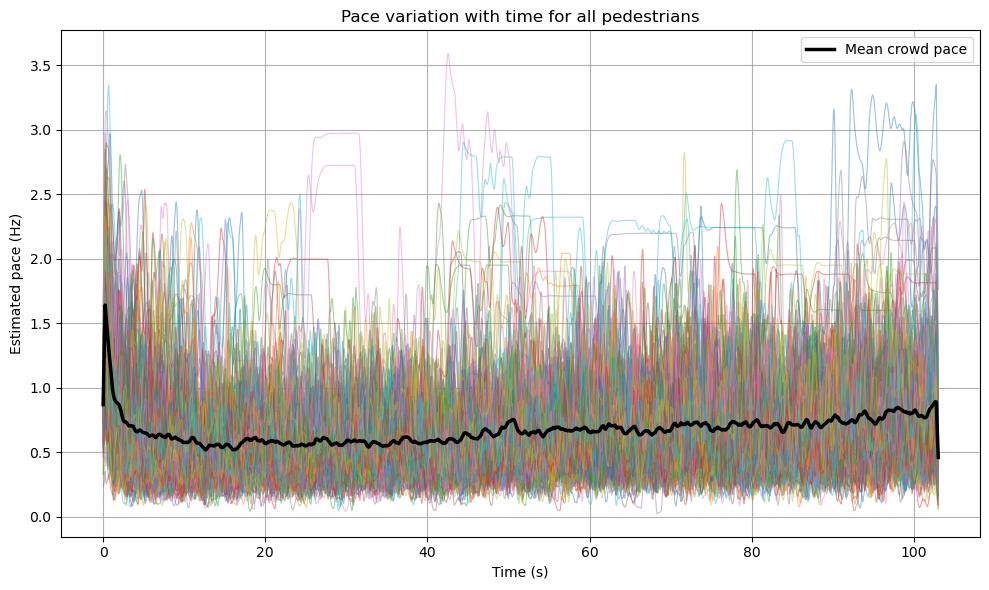

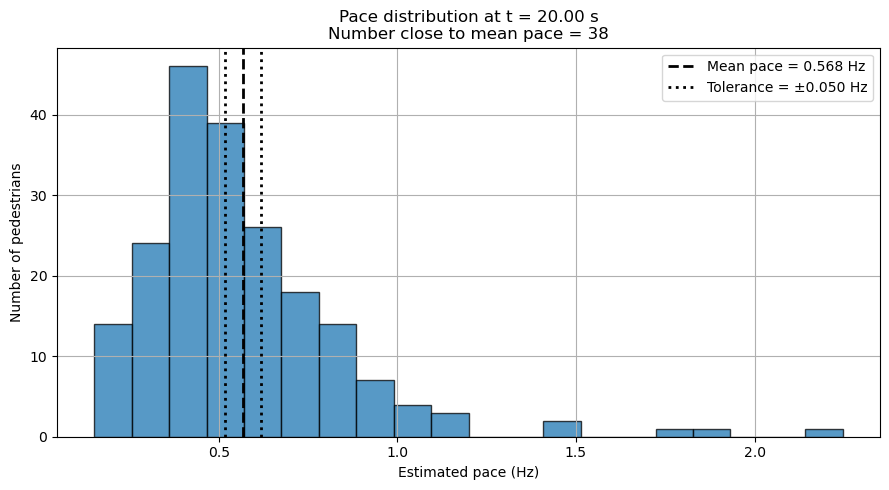


Selected-time mean-pace synchronisation
--------------------------------------
Selected time = 20.00 s
Mean crowd pace = 0.568 Hz
Tolerance = ±0.050 Hz
Number of pedestrians = 200
Number close to mean pace = 38
Fraction close to mean pace = 0.190


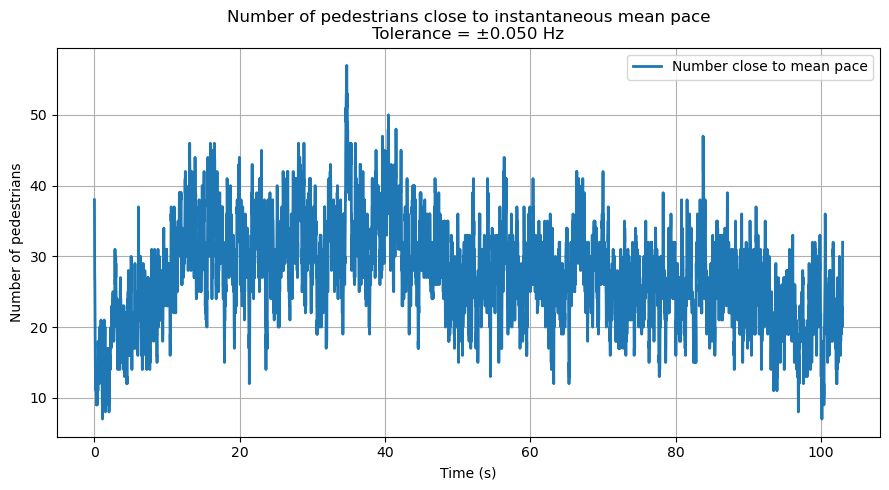

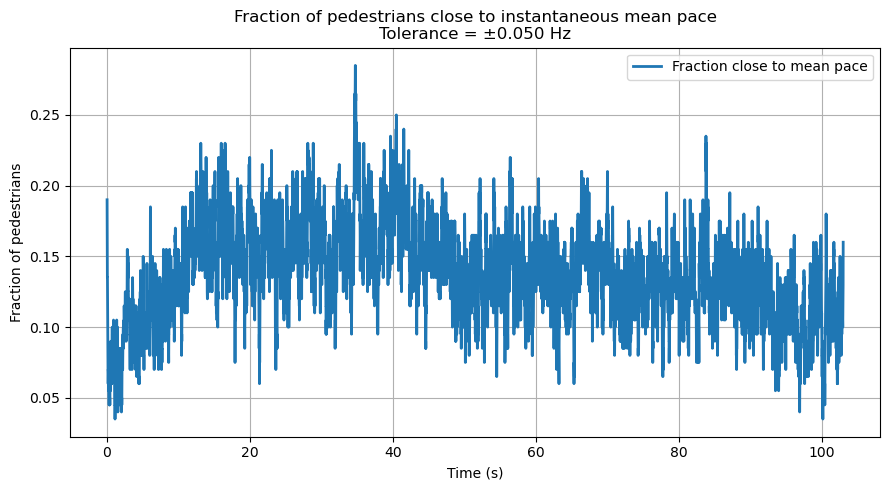


Overall crowd statistics
------------------------
Mean absolute velocity = 0.4869 m/s
SD absolute velocity   = 0.2494 m/s
Mean pace              = 0.6684 Hz
SD pace                = 0.3575 Hz

Selected-time crowd statistics
------------------------------
Selected time          = 20.00 s
Mean absolute velocity = 0.4147 m/s
SD absolute velocity   = 0.2083 m/s
Mean pace              = 0.5677 Hz
SD pace                = 0.2884 Hz


In [62]:
import numpy as np
import matplotlib.pyplot as plt
import socialforce
import numpy as np
import torch
from socialforcefunctions import initial_state_corridor
import pandas as pd
from matrix import*  
from solver import *
from pedestrian import* 
from matplotlib import pyplot as plt
from pacesyncedhelper import analyse_pace_synchronisation

#_____________________________________________________________Crowd Generator________________________________________________________________________________
length = 50.0
width = 2.0
hht =0.01
meanvelocity = 1.34
stddev = 0.19

t =np.arange(0, (length+88) / meanvelocity, hht)
totalTimeSteps = np.size(t)
print(np.size(t))

tocity = 100 #bounded_gamma_sample1(16.7,12.0,0.0,67.0)
print(tocity)
outcity = 100 #bounded_gamma_sample1(9.4,4.1,1.0,21.0)
print(outcity)


initial_state = initial_state_corridor(tocity,outcity,length,width,meanvelocity,stddev)
   


upper_wall = torch.stack([torch.linspace(0, length, 1000), torch.full((1000,), width)], -1)
lower_wall = torch.stack([torch.linspace(0, length, 1000), torch.full((1000,), 0)], -1)
ped_space = socialforce.potentials.PedSpacePotential([upper_wall, lower_wall])

#ped_ped = socialforce.potentials.PedPedPotential()
#ped_ped = socialforce.potentials.PedPedPotentialDiamond(sigma=0.5)
ped_ped = socialforce.potentials.PedPedPotentialDiamond(sigma=0.5, asymmetry_angle=-20.0)
#ped_ped = socialforce.potentials.PedPedPotential2D()


simulator = socialforce.Simulator(ped_ped=ped_ped, ped_space=ped_space,
                                  oversampling=1, delta_t=hht)
simulator.integrator = socialforce.simulator.PeriodicBoundary(
        simulator.integrator, x_boundary=[0, +length])

with torch.no_grad():
        states_sf = simulator.run(initial_state, totalTimeSteps)


#__________________________________________________________________end of crowd generator_________________________________________________________________________




#__________________________________________________________________Extracting the coordinates_______________________________________________________________________

# Extract the number of pedestrians and timesteps
num_timesteps = len(states_sf)
#print(states_sf.size())
num_pedestrians = states_sf[0].shape[0]
#print("Number of pedestrians:", num_pedestrians)
#print("Number of timesteps:", num_timesteps)

# Create an array to store the variations in coordinates
x_coords = np.zeros((num_timesteps, num_pedestrians))
y_coords = np.zeros((num_timesteps, num_pedestrians))

# Fill in the matrix
for t in range(num_timesteps):
    x_coords[t, :] = states_sf[t][:, 0].numpy()  # Extract x-coordinates
    y_coords[t, :] = states_sf[t][:, 1].numpy()  # Extract y-coordinates




# ==================================================
# SETTINGS
# ==================================================

dt = hht
bridge_length = length

pedestrian_id = 0          # pedestrian to plot
selected_time = 20.0       # time at which to inspect crowd paces

# Target pace for synchronisation
# Option 1: use bridge frequency
#target_pace = BeamFreq[0]

# Option 2: use preferred walking pace
target_pace = 2.0

pace_tolerance = 0.05      # Hz, adjustable
smooth_sec = 0.5           # smoothing window for velocity

stride_mean = 0.75         # m
stride_sd = 0.08           # m



sync_data = analyse_pace_synchronisation(
    x_coords=x_coords,
    y_coords=y_coords,
    bridge_length=bridge_length,
    dt=dt,
    pace_tolerance=pace_tolerance,
    stride_mean=stride_mean,
    stride_sd=stride_sd,
    smooth_sec=smooth_sec,
    seed=None,
    velocity_mode ="2d"
)


# ==================================================
# PLOT 1: ABSOLUTE VELOCITY VARIATION OF ALL PEDESTRIANS
# ==================================================

time_velocity = sync_data["time_velocity"]
speed_x_smooth = sync_data["speed_x_smooth"]

num_pedestrians = speed_x_smooth.shape[1]

# Mean absolute velocity at each time step
mean_speed_time = np.mean(speed_x_smooth, axis=1)

plt.figure(figsize=(10, 6))

for j in range(num_pedestrians):
    plt.plot(
        time_velocity,
        speed_x_smooth[:, j],
        linewidth=0.8,
        alpha=0.45
    )

plt.plot(
    time_velocity,
    mean_speed_time,
    color="black",
    linewidth=2.5,
    label="Mean absolute velocity"
)

plt.xlabel("Time (s)")
plt.ylabel("Absolute longitudinal velocity (m/s)")
plt.title("Absolute velocity variation with time for all pedestrians")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ==================================================
# PLOT 2: PACE VARIATION OF ALL PEDESTRIANS
# ==================================================

estimated_pace = sync_data["estimated_pace"]
mean_pace_time = sync_data["mean_pace_time"]

plt.figure(figsize=(10, 6))

for j in range(num_pedestrians):
    plt.plot(
        time_velocity,
        estimated_pace[:, j],
        linewidth=0.8,
        alpha=0.45
    )

plt.plot(
    time_velocity,
    mean_pace_time,
    color="black",
    linewidth=2.5,
    label="Mean crowd pace"
)

plt.xlabel("Time (s)")
plt.ylabel("Estimated pace (Hz)")
plt.title("Pace variation with time for all pedestrians")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ==================================================
# PLOT 3: AT ONE TIME, HOW MANY HAVE ALMOST SAME PACE
# ==================================================

selected_idx = np.argmin(np.abs(time_velocity - selected_time))

pace_at_selected_time = estimated_pace[selected_idx, :]
mean_pace_selected = mean_pace_time[selected_idx]

sync_at_selected_time = (
    np.abs(pace_at_selected_time - mean_pace_selected) <= pace_tolerance
)

n_sync_selected = np.sum(sync_at_selected_time)

plt.figure(figsize=(9, 5))

plt.hist(
    pace_at_selected_time,
    bins=20,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    mean_pace_selected,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Mean pace = {mean_pace_selected:.3f} Hz"
)

plt.axvline(
    mean_pace_selected - pace_tolerance,
    color="black",
    linestyle=":",
    linewidth=2,
    label=f"Tolerance = ±{pace_tolerance:.3f} Hz"
)

plt.axvline(
    mean_pace_selected + pace_tolerance,
    color="black",
    linestyle=":",
    linewidth=2
)

plt.xlabel("Estimated pace (Hz)")
plt.ylabel("Number of pedestrians")
plt.title(
    f"Pace distribution at t = {time_velocity[selected_idx]:.2f} s\n"
    f"Number close to mean pace = {n_sync_selected}"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("\nSelected-time mean-pace synchronisation")
print("--------------------------------------")
print(f"Selected time = {time_velocity[selected_idx]:.2f} s")
print(f"Mean crowd pace = {mean_pace_selected:.3f} Hz")
print(f"Tolerance = ±{pace_tolerance:.3f} Hz")
print(f"Number of pedestrians = {estimated_pace.shape[1]}")
print(f"Number close to mean pace = {n_sync_selected}")
print(f"Fraction close to mean pace = {n_sync_selected / estimated_pace.shape[1]:.3f}")


# ==================================================
# PLOT 4: NUMBER OF PACE-SYNCHRONISED PEDESTRIANS WITH TIME
# ==================================================

n_sync_time = sync_data["n_sync_time"]
frac_sync_time = sync_data["frac_sync_time"]

plt.figure(figsize=(9, 5))

plt.plot(
    time_velocity,
    n_sync_time,
    linewidth=2,
    label="Number close to mean pace"
)

plt.xlabel("Time (s)")
plt.ylabel("Number of pedestrians")
plt.title(
    f"Number of pedestrians close to instantaneous mean pace\n"
    f"Tolerance = ±{pace_tolerance:.3f} Hz"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ==================================================
# PLOT 5: FRACTION OF PEDESTRIANS CLOSE TO MEAN PACE WITH TIME
# ==================================================

plt.figure(figsize=(9, 5))

plt.plot(
    time_velocity,
    frac_sync_time,
    linewidth=2,
    label="Fraction close to mean pace"
)

plt.xlabel("Time (s)")
plt.ylabel("Fraction of pedestrians")
plt.title(
    f"Fraction of pedestrians close to instantaneous mean pace\n"
    f"Tolerance = ±{pace_tolerance:.3f} Hz"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ==================================================
# PRINT MEAN AND SD OF ABSOLUTE VELOCITY AND PACE
# ==================================================

speed_x_smooth = sync_data["speed_x_smooth"]      # absolute smoothed velocity
estimated_pace = sync_data["estimated_pace"]      # estimated pace
time_velocity = sync_data["time_velocity"]

# --------------------------------------------------
# Overall statistics across all pedestrians and all time steps
# --------------------------------------------------
mean_velocity_all = np.nanmean(speed_x_smooth)
sd_velocity_all = np.nanstd(speed_x_smooth, ddof=1)

mean_pace_all = np.nanmean(estimated_pace)
sd_pace_all = np.nanstd(estimated_pace, ddof=1)

print("\nOverall crowd statistics")
print("------------------------")
print(f"Mean absolute velocity = {mean_velocity_all:.4f} m/s")
print(f"SD absolute velocity   = {sd_velocity_all:.4f} m/s")
print(f"Mean pace              = {mean_pace_all:.4f} Hz")
print(f"SD pace                = {sd_pace_all:.4f} Hz")


# --------------------------------------------------
# Statistics at selected time
# --------------------------------------------------
selected_idx = np.argmin(np.abs(time_velocity - selected_time))

velocity_at_selected_time = speed_x_smooth[selected_idx, :]
pace_at_selected_time = estimated_pace[selected_idx, :]

mean_velocity_selected = np.nanmean(velocity_at_selected_time)
sd_velocity_selected = np.nanstd(velocity_at_selected_time, ddof=1)

mean_pace_selected = np.nanmean(pace_at_selected_time)
sd_pace_selected = np.nanstd(pace_at_selected_time, ddof=1)

print("\nSelected-time crowd statistics")
print("------------------------------")
print(f"Selected time          = {time_velocity[selected_idx]:.2f} s")
print(f"Mean absolute velocity = {mean_velocity_selected:.4f} m/s")
print(f"SD absolute velocity   = {sd_velocity_selected:.4f} m/s")
print(f"Mean pace              = {mean_pace_selected:.4f} Hz")
print(f"SD pace                = {sd_pace_selected:.4f} Hz")

In [63]:
# ==================================================
# PRINT OVERALL SYNCHRONISATION DISTRIBUTION STATS
# ==================================================

n_sync_time = np.asarray(sync_data["n_sync_time"], dtype=float)
frac_sync_time = np.asarray(sync_data["frac_sync_time"], dtype=float)
time_velocity = np.asarray(sync_data["time_velocity"], dtype=float)

# Keep only valid values
valid = np.isfinite(n_sync_time) & np.isfinite(frac_sync_time)

n_sync_valid = n_sync_time[valid]
frac_sync_valid = frac_sync_time[valid]
time_valid = time_velocity[valid]

num_pedestrians = estimated_pace.shape[1]

print("\nOverall synchronisation distribution statistics")
print("------------------------------------------------")
print(f"Number of pedestrians                  = {num_pedestrians}")
print(f"Number of time samples used             = {len(n_sync_valid)}")
print(f"Tolerance used                          = ±{pace_tolerance:.4f} Hz")

print("\nNumber of synchronised pedestrians over time")
print("---------------------------------------------")
print(f"Mean n_sync                              = {np.mean(n_sync_valid):.3f}")
print(f"SD n_sync                                = {np.std(n_sync_valid, ddof=1):.3f}")
print(f"Minimum n_sync                           = {np.min(n_sync_valid):.0f}")
print(f"5th percentile n_sync                    = {np.percentile(n_sync_valid, 5):.3f}")
print(f"25th percentile n_sync                   = {np.percentile(n_sync_valid, 25):.3f}")
print(f"Median n_sync                            = {np.percentile(n_sync_valid, 50):.3f}")
print(f"75th percentile n_sync                   = {np.percentile(n_sync_valid, 75):.3f}")
print(f"95th percentile n_sync                   = {np.percentile(n_sync_valid, 95):.3f}")
print(f"Maximum n_sync                           = {np.max(n_sync_valid):.0f}")

print("\nFraction of synchronised pedestrians over time")
print("-----------------------------------------------")
print(f"Mean fraction synced                     = {np.mean(frac_sync_valid):.4f}")
print(f"SD fraction synced                       = {np.std(frac_sync_valid, ddof=1):.4f}")
print(f"Minimum fraction synced                  = {np.min(frac_sync_valid):.4f}")
print(f"5th percentile fraction synced           = {np.percentile(frac_sync_valid, 5):.4f}")
print(f"25th percentile fraction synced          = {np.percentile(frac_sync_valid, 25):.4f}")
print(f"Median fraction synced                   = {np.percentile(frac_sync_valid, 50):.4f}")
print(f"75th percentile fraction synced          = {np.percentile(frac_sync_valid, 75):.4f}")
print(f"95th percentile fraction synced          = {np.percentile(frac_sync_valid, 95):.4f}")
print(f"Maximum fraction synced                  = {np.max(frac_sync_valid):.4f}")

# Time when maximum synchronisation occurs
idx_max_sync = np.argmax(n_sync_valid)

print("\nMaximum synchronisation event")
print("-----------------------------")
print(f"Time of maximum n_sync                  = {time_valid[idx_max_sync]:.3f} s")
print(f"Maximum n_sync                          = {n_sync_valid[idx_max_sync]:.0f}")
print(f"Maximum fraction synced                 = {frac_sync_valid[idx_max_sync]:.4f}")


Overall synchronisation distribution statistics
------------------------------------------------
Number of pedestrians                  = 200
Number of time samples used             = 10299
Tolerance used                          = ±0.0500 Hz

Number of synchronised pedestrians over time
---------------------------------------------
Mean n_sync                              = 27.486
SD n_sync                                = 6.728
Minimum n_sync                           = 7
5th percentile n_sync                    = 17.000
25th percentile n_sync                   = 23.000
Median n_sync                            = 27.000
75th percentile n_sync                   = 32.000
95th percentile n_sync                   = 39.000
Maximum n_sync                           = 57

Fraction of synchronised pedestrians over time
-----------------------------------------------
Mean fraction synced                     = 0.1374
SD fraction synced                       = 0.0336
Minimum fraction synced     

In [64]:
# ==================================================
# ANIMATED GIF: PEDESTRIAN MOTION + VELOCITY + PACE
# ==================================================

from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML, display
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# DATA FROM YOUR EXISTING CODE
# -----------------------------
time_velocity = sync_data["time_velocity"]
speed_x_smooth = sync_data["speed_x_smooth"]
estimated_pace = sync_data["estimated_pace"]
mean_pace_time = sync_data["mean_pace_time"]
pace_tolerance = sync_data["pace_tolerance"]
n_sync_time = sync_data["n_sync_time"]
frac_sync_time = sync_data["frac_sync_time"]
num_pedestrians = estimated_pace.shape[1]

# -----------------------------
# ANIMATION SETTINGS
# -----------------------------
frame_stride = 25   # use every 25th timestep. Increase to make GIF smaller/faster
fps = 20
gif_name = "pedestrian_motion_velocity_pace200_twwodirection.gif"

frames = np.arange(0, len(time_velocity), frame_stride)

# Mean velocity with time
mean_speed_time = np.mean(speed_x_smooth, axis=1)

# Axis limits
v_min, v_max = np.nanpercentile(speed_x_smooth, [1, 99])
p_min, p_max = np.nanpercentile(estimated_pace, [1, 99])

v_pad = 0.15 * (v_max - v_min)
p_pad = 0.15 * (p_max - p_min)

# -----------------------------
# FIGURE SETUP
# -----------------------------
fig, axes = plt.subplots(
    4, 1,
    figsize=(9, 6),
    gridspec_kw={"height_ratios": [1.0, 1.0, 1.0, 0.8]}
)

ax_motion, ax_vel, ax_pace, ax_sync = axes

# ==================================================
# PANEL 1: PEDESTRIAN MOTION
# ==================================================

scatter = ax_motion.scatter([], [], s=35)

ax_motion.set_xlim(0, length)
ax_motion.set_ylim(0, width)
ax_motion.set_xlabel("Bridge length x (m)")
ax_motion.set_ylabel("Bridge width y (m)")
ax_motion.set_title("Pedestrian motion on bridge")
ax_motion.grid(True)

time_text = ax_motion.text(
    0.02, 0.88,
    "",
    transform=ax_motion.transAxes,
    fontsize=11,
    bbox=dict(facecolor="white", alpha=0.8)
)

# ==================================================
# PANEL 2: VELOCITY TIME HISTORIES
# ==================================================

vel_lines = []
for j in range(num_pedestrians):
    line, = ax_vel.plot([], [], linewidth=0.8, alpha=0.35)
    vel_lines.append(line)

mean_vel_line, = ax_vel.plot(
    [],
    [],
    color="black",
    linewidth=2.5,
    label="Mean velocity"
)

current_vel_line = ax_vel.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.5
)

ax_vel.set_xlim(time_velocity[0], time_velocity[-1])
ax_vel.set_ylim(v_min - v_pad, v_max + v_pad)
ax_vel.set_xlabel("Time (s)")
#ax_vel.set_ylabel("Absolute longitudinal velocity (m/s)")
ax_vel.set_title("Absolute velocity variation with time for all pedestrians")
ax_vel.grid(True)
ax_vel.legend(loc="upper right")

# ==================================================
# PANEL 3: PACE TIME HISTORIES
# ==================================================

pace_lines = []
for j in range(num_pedestrians):
    line, = ax_pace.plot([], [], linewidth=0.8, alpha=0.30)
    pace_lines.append(line)

mean_pace_line, = ax_pace.plot(
    [],
    [],
    color="black",
    linewidth=2.5,
    label="Mean crowd pace"
)

upper_tol_line, = ax_pace.plot(
    [],
    [],
    color="black",
    linestyle=":",
    linewidth=1.5,
    label=f"Mean ± {pace_tolerance:.3f} Hz"
)

lower_tol_line, = ax_pace.plot(
    [],
    [],
    color="black",
    linestyle=":",
    linewidth=1.5
)

current_pace_line = ax_pace.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.5
)

ax_pace.set_xlim(time_velocity[0], time_velocity[-1])
ax_pace.set_ylim(p_min - p_pad, p_max + p_pad)
ax_pace.set_xlabel("Time (s)")
#ax_pace.set_ylabel("Estimated pace (Hz)")
ax_pace.set_title("Pace variation with time for all pedestrians")
ax_pace.grid(True)
ax_pace.legend(loc="upper right")

# ==================================================
# PANEL 4: NUMBER OF SYNCED PEDESTRIANS
# ==================================================

n_sync_line, = ax_sync.plot(
    [],
    [],
    color="black",
    linewidth=2.5,
    label=r"$n_{\mathrm{sync}}(t)$"
)

n_sync_marker, = ax_sync.plot(
    [],
    [],
    marker="o",
    color="black",
    markersize=6
)

current_sync_line = ax_sync.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.5
)

ax_sync.set_xlim(time_velocity[0], time_velocity[-1])
ax_sync.set_ylim(0, np.nanmax(n_sync_time) * 1.15)
ax_sync.set_xlabel("Time (s)")
ax_sync.set_ylabel("Synced pedestrians")
ax_sync.set_title("Number of pedestrians close to instantaneous mean pace")
ax_sync.grid(True)
ax_sync.legend(loc="upper right")
plt.tight_layout()


# ==================================================
# UPDATE FUNCTION
# ==================================================

def update(frame_id):
    k = frames[frame_id]

    current_time = time_velocity[k]

    # -----------------------------
    # Pedestrian positions
    # x_coords/y_coords have one extra row compared with vx/pace,
    # so use k+1 for position.
    # -----------------------------
    scatter.set_offsets(
        np.column_stack((x_coords[k + 1, :], y_coords[k + 1, :]))
    )

    time_text.set_text(f"t = {current_time:.2f} s")

    # -----------------------------
    # Velocity histories up to current time
    # -----------------------------
    tt = time_velocity[:k + 1]

    for j in range(num_pedestrians):
        vel_lines[j].set_data(tt, speed_x_smooth[:k + 1, j])

    mean_vel_line.set_data(tt, mean_speed_time[:k + 1])
    current_vel_line.set_xdata([current_time, current_time])

    # -----------------------------
    # Pace histories up to current time
    # -----------------------------
    for j in range(num_pedestrians):
        pace_lines[j].set_data(tt, estimated_pace[:k + 1, j])

    mean_pace_line.set_data(tt, mean_pace_time[:k + 1])
    upper_tol_line.set_data(tt, mean_pace_time[:k + 1] + pace_tolerance)
    lower_tol_line.set_data(tt, mean_pace_time[:k + 1] - pace_tolerance)
    current_pace_line.set_xdata([current_time, current_time])
    # -----------------------------
    # Synced pedestrian count up to current time
    # -----------------------------
    n_sync_line.set_data(tt, n_sync_time[:k + 1])
    n_sync_marker.set_data([current_time], [n_sync_time[k]])
    current_sync_line.set_xdata([current_time, current_time])
    
    return (
        [scatter, time_text, mean_vel_line, current_vel_line,
         mean_pace_line, upper_tol_line, lower_tol_line, current_pace_line]
        + vel_lines
        + pace_lines
        + [n_sync_line, n_sync_marker, current_sync_line]
    )


# ==================================================
# CREATE AND SAVE GIF
# ==================================================

anim = FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=1000 / fps,
    blit=False
)

anim.save(
    gif_name,
    writer=PillowWriter(fps=fps)
)

plt.close(fig)

print(f"Saved GIF as: {gif_name}")

Saved GIF as: pedestrian_motion_velocity_pace200_twwodirection.gif


In [34]:
# ==================================================
# ANIMATED GIF: PEDESTRIAN MOTION + VELOCITY + PACE
# ==================================================

from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML, display
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# DATA FROM YOUR EXISTING CODE
# -----------------------------
time_velocity = sync_data["time_velocity"]
speed_x_smooth = sync_data["speed_x_smooth"]
estimated_pace = sync_data["estimated_pace"]
mean_pace_time = sync_data["mean_pace_time"]
pace_tolerance = sync_data["pace_tolerance"]

num_pedestrians = estimated_pace.shape[1]

# -----------------------------
# ANIMATION SETTINGS
# -----------------------------
frame_stride = 25   # use every 25th timestep. Increase to make GIF smaller/faster
fps = 20
gif_name = "pedestrian_motion_velocity_pace1.gif"

frames = np.arange(0, len(time_velocity), frame_stride)

# Mean velocity with time
mean_speed_time = np.mean(speed_x_smooth, axis=1)

# Axis limits
v_min, v_max = np.nanpercentile(speed_x_smooth, [1, 99])
p_min, p_max = np.nanpercentile(estimated_pace, [1, 99])

v_pad = 0.15 * (v_max - v_min)
p_pad = 0.15 * (p_max - p_min)

# -----------------------------
# FIGURE SETUP
# -----------------------------
fig, axes = plt.subplots(
    3, 1,
    figsize=(9, 4),
    gridspec_kw={"height_ratios": [1.0, 1.0, 1.0]}
)

ax_motion, ax_vel, ax_pace = axes

# ==================================================
# PANEL 1: PEDESTRIAN MOTION
# ==================================================

scatter = ax_motion.scatter([], [], s=35)

ax_motion.set_xlim(0, length)
ax_motion.set_ylim(0, width)
ax_motion.set_xlabel("Bridge length x (m)")
ax_motion.set_ylabel("Bridge width y (m)")
ax_motion.set_title("Pedestrian motion on bridge")
ax_motion.grid(True)

time_text = ax_motion.text(
    0.02, 0.88,
    "",
    transform=ax_motion.transAxes,
    fontsize=11,
    bbox=dict(facecolor="white", alpha=0.8)
)

# ==================================================
# PANEL 2: VELOCITY TIME HISTORIES
# ==================================================

vel_lines = []
for j in range(num_pedestrians):
    line, = ax_vel.plot([], [], linewidth=0.8, alpha=0.35)
    vel_lines.append(line)

mean_vel_line, = ax_vel.plot(
    [],
    [],
    color="black",
    linewidth=2.5,
    label="Mean velocity"
)

current_vel_line = ax_vel.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.5
)

ax_vel.set_xlim(time_velocity[0], time_velocity[-1])
ax_vel.set_ylim(v_min - v_pad, v_max + v_pad)
ax_vel.set_xlabel("Time (s)")
#ax_vel.set_ylabel("Absolute longitudinal velocity (m/s)")
ax_vel.set_title("Absolute velocity variation with time for all pedestrians")
ax_vel.grid(True)
ax_vel.legend(loc="upper right")

# ==================================================
# PANEL 3: PACE TIME HISTORIES
# ==================================================

pace_lines = []
for j in range(num_pedestrians):
    line, = ax_pace.plot([], [], linewidth=0.8, alpha=0.30)
    pace_lines.append(line)

mean_pace_line, = ax_pace.plot(
    [],
    [],
    color="black",
    linewidth=2.5,
    label="Mean crowd pace"
)

upper_tol_line, = ax_pace.plot(
    [],
    [],
    color="black",
    linestyle=":",
    linewidth=1.5,
    label=f"Mean ± {pace_tolerance:.3f} Hz"
)

lower_tol_line, = ax_pace.plot(
    [],
    [],
    color="black",
    linestyle=":",
    linewidth=1.5
)

current_pace_line = ax_pace.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.5
)

ax_pace.set_xlim(time_velocity[0], time_velocity[-1])
ax_pace.set_ylim(p_min - p_pad, p_max + p_pad)
ax_pace.set_xlabel("Time (s)")
#ax_pace.set_ylabel("Estimated pace (Hz)")
ax_pace.set_title("Pace variation with time for all pedestrians")
ax_pace.grid(True)
ax_pace.legend(loc="upper right")

plt.tight_layout()


# ==================================================
# UPDATE FUNCTION
# ==================================================

def update(frame_id):
    k = frames[frame_id]

    current_time = time_velocity[k]

    # -----------------------------
    # Pedestrian positions
    # x_coords/y_coords have one extra row compared with vx/pace,
    # so use k+1 for position.
    # -----------------------------
    scatter.set_offsets(
        np.column_stack((x_coords[k + 1, :], y_coords[k + 1, :]))
    )

    time_text.set_text(f"t = {current_time:.2f} s")

    # -----------------------------
    # Velocity histories up to current time
    # -----------------------------
    tt = time_velocity[:k + 1]

    for j in range(num_pedestrians):
        vel_lines[j].set_data(tt, speed_x_smooth[:k + 1, j])

    mean_vel_line.set_data(tt, mean_speed_time[:k + 1])
    current_vel_line.set_xdata([current_time, current_time])

    # -----------------------------
    # Pace histories up to current time
    # -----------------------------
    for j in range(num_pedestrians):
        pace_lines[j].set_data(tt, estimated_pace[:k + 1, j])

    mean_pace_line.set_data(tt, mean_pace_time[:k + 1])
    upper_tol_line.set_data(tt, mean_pace_time[:k + 1] + pace_tolerance)
    lower_tol_line.set_data(tt, mean_pace_time[:k + 1] - pace_tolerance)
    current_pace_line.set_xdata([current_time, current_time])

    return (
        [scatter, time_text, mean_vel_line, current_vel_line,
         mean_pace_line, upper_tol_line, lower_tol_line, current_pace_line]
        + vel_lines
        + pace_lines
    )


# ==================================================
# CREATE AND SAVE GIF
# ==================================================

anim = FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=1000 / fps,
    blit=False
)

anim.save(
    gif_name,
    writer=PillowWriter(fps=fps)
)

plt.close(fig)

print(f"Saved GIF as: {gif_name}")

Saved GIF as: pedestrian_motion_velocity_pace1.gif


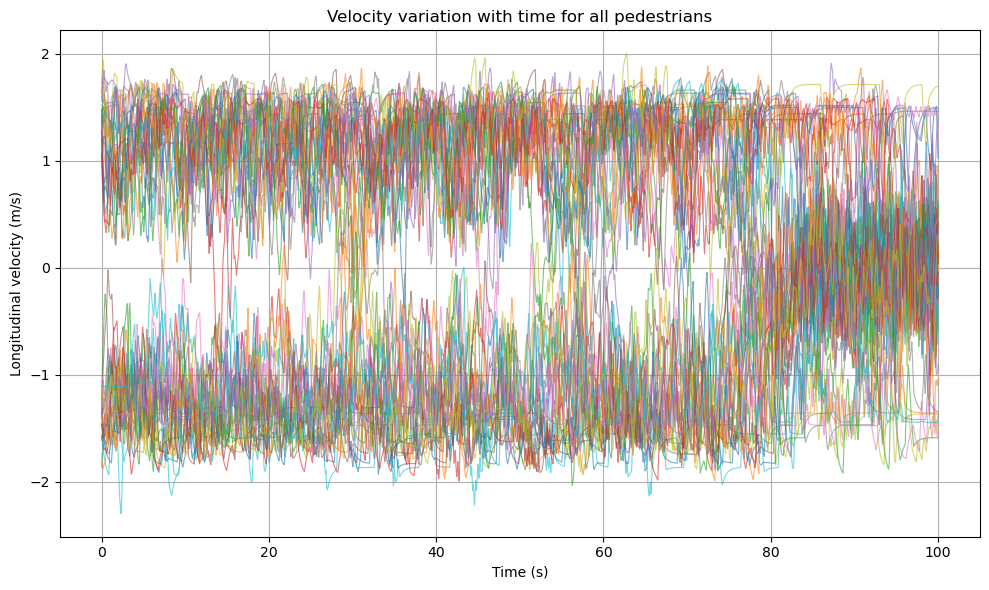

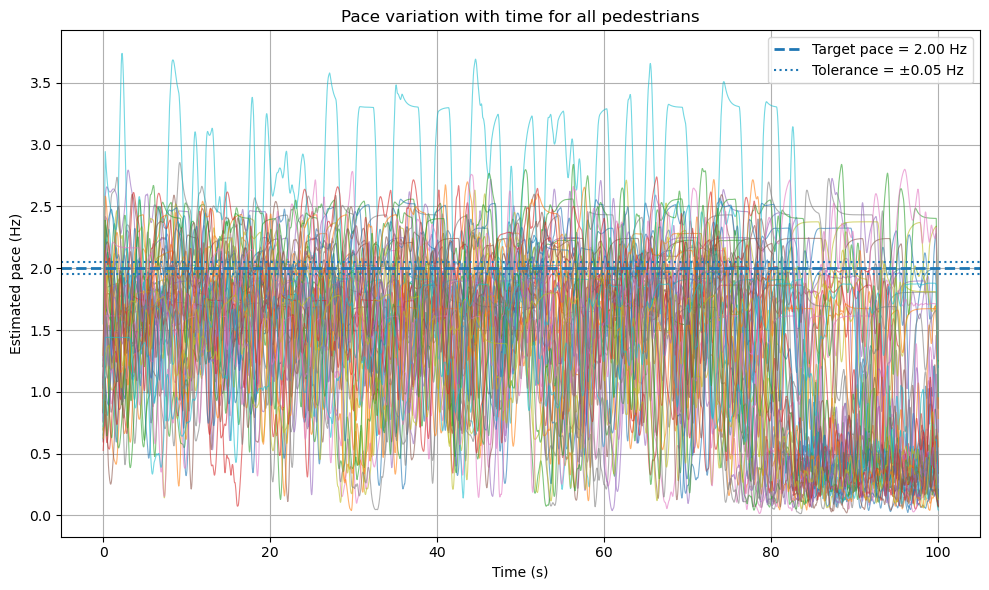

In [4]:
# ==================================================
# PLOT 1: VELOCITY VARIATION OF ALL PEDESTRIANS
# ==================================================

time_velocity = sync_data["time_velocity"]
vx = sync_data["vx"]                         # signed longitudinal velocity
speed_x_smooth = sync_data["speed_x_smooth"] # smoothed absolute velocity

num_pedestrians = vx.shape[1]

plt.figure(figsize=(10, 6))

for j in range(num_pedestrians):
    plt.plot(
        time_velocity,
        vx[:, j],
        linewidth=0.8,
        alpha=0.6
    )

plt.xlabel("Time (s)")
plt.ylabel("Longitudinal velocity (m/s)")
plt.title("Velocity variation with time for all pedestrians")
plt.grid(True)
plt.tight_layout()
plt.show()

# ==================================================
# PLOT 2: PACE VARIATION OF ALL PEDESTRIANS
# ==================================================

estimated_pace = sync_data["estimated_pace"]

plt.figure(figsize=(10, 6))

for j in range(num_pedestrians):
    plt.plot(
        time_velocity,
        estimated_pace[:, j],
        linewidth=0.8,
        alpha=0.6
    )

plt.axhline(
    target_pace,
    linestyle="--",
    linewidth=2,
    label=f"Target pace = {target_pace:.2f} Hz"
)

plt.axhline(
    target_pace + pace_tolerance,
    linestyle=":",
    linewidth=1.5,
    label=f"Tolerance = ±{pace_tolerance:.2f} Hz"
)

plt.axhline(
    target_pace - pace_tolerance,
    linestyle=":",
    linewidth=1.5
)

plt.xlabel("Time (s)")
plt.ylabel("Estimated pace (Hz)")
plt.title("Pace variation with time for all pedestrians")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Total time steps: 9518
To city: 30
Out city: 30
Number of pedestrians: 60
Number of timesteps: 9519


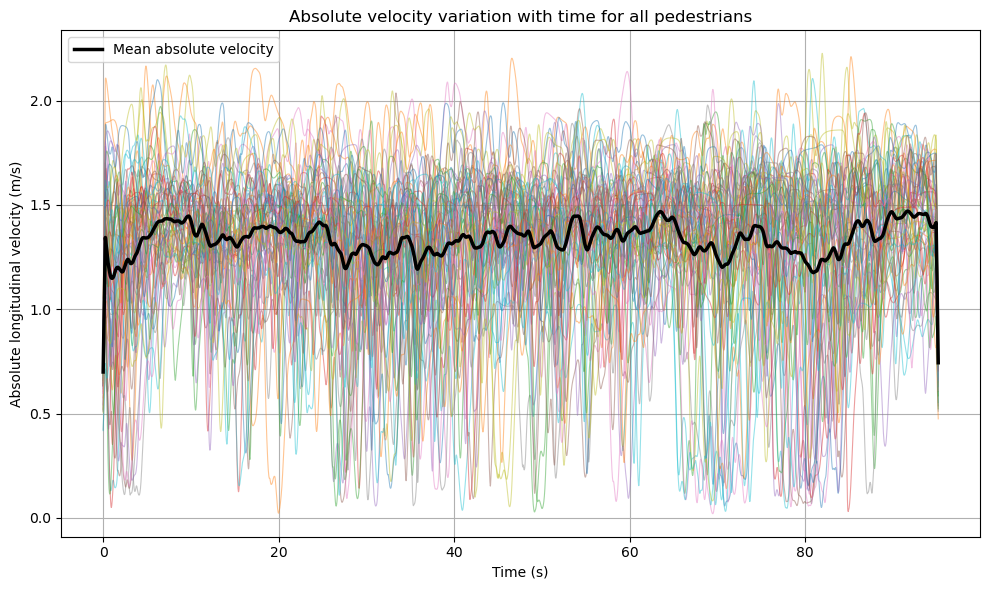

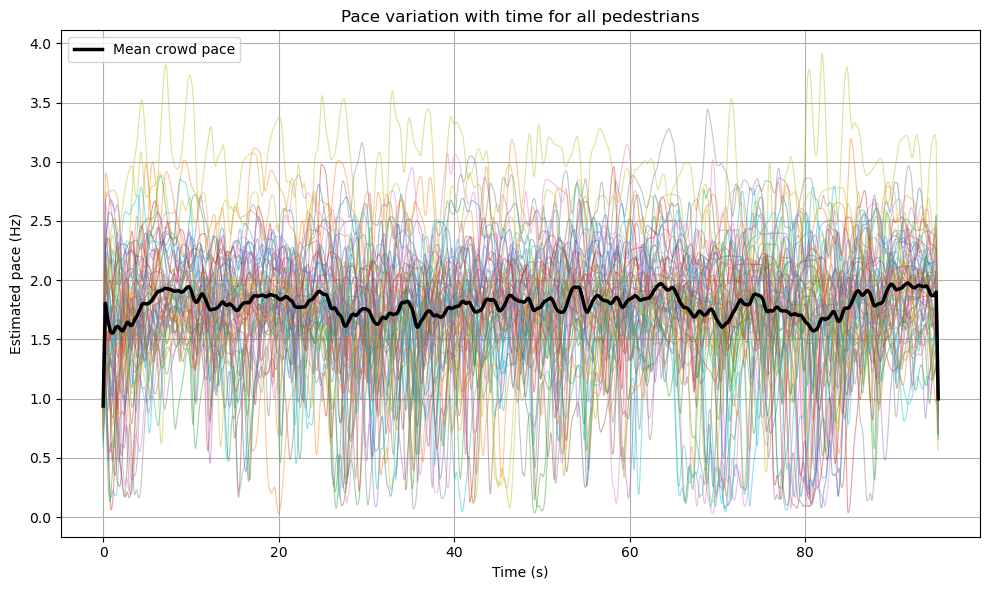

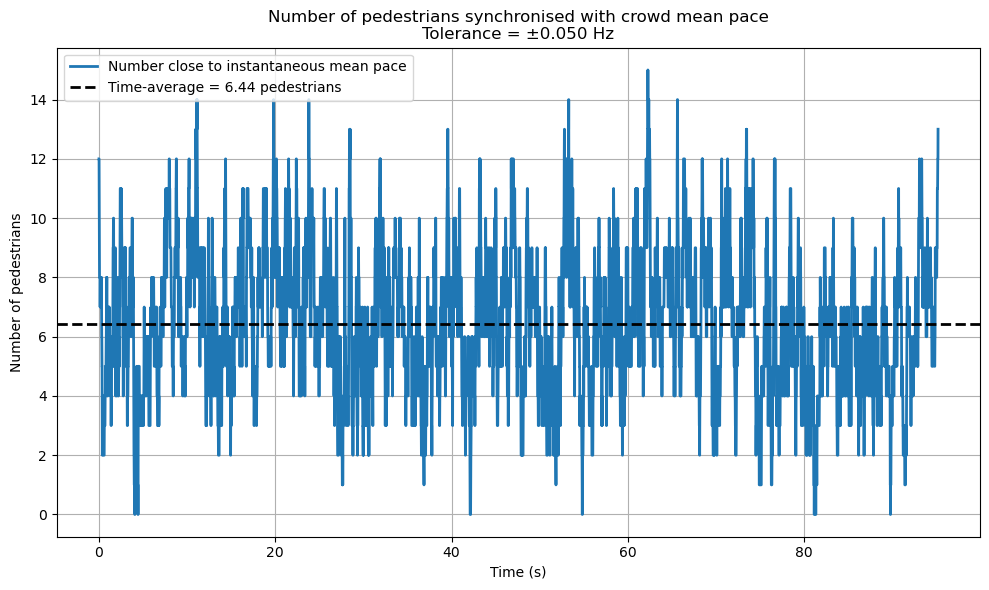

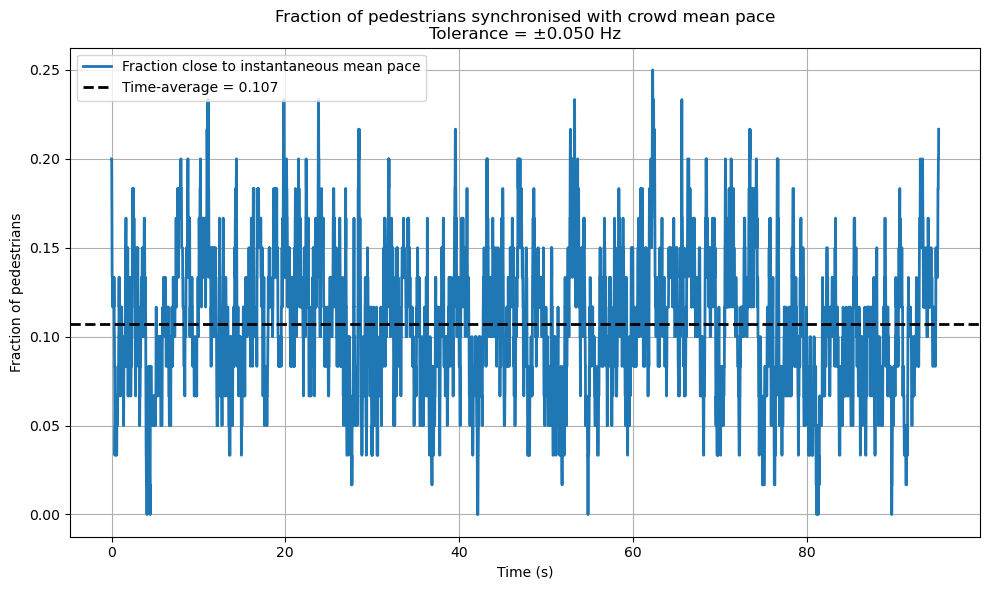

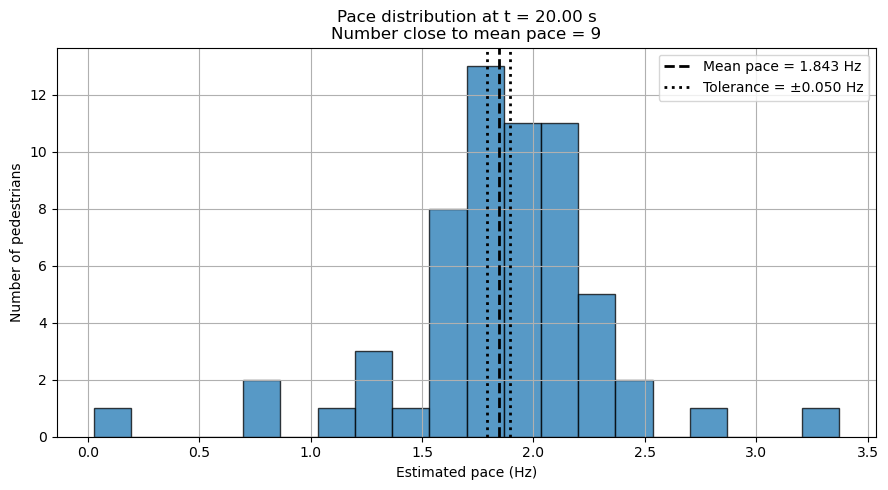


Overall crowd statistics
------------------------
Mean absolute velocity                  = 1.3340 m/s
SD absolute velocity                    = 0.3284 m/s
Overall mean pace                       = 1.7903 Hz
Overall SD pace                         = 0.4983 Hz

Synchronisation with instantaneous crowd mean pace
--------------------------------------------------
Tolerance                                = ±0.0500 Hz
Number of pedestrians                    = 60
Mean number synchronised over time       = 6.4400
SD number synchronised over time         = 2.3774
Mean fraction synchronised over time     = 0.1073
SD fraction synchronised over time       = 0.0396
Mean percentage synchronised over time   = 10.73%

Selected-time crowd statistics
------------------------------
Selected time                           = 20.00 s
Mean absolute velocity at selected time = 1.3733 m/s
SD absolute velocity at selected time   = 0.3179 m/s
Mean pace at selected time              = 1.8430 Hz
SD pace at sele

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import socialforce
import torch
from socialforcefunctions import initial_state_corridor
import pandas as pd
from matrix import *
from solver import *
from pedestrian import *


# _____________________________________________________________
# Crowd Generator
# _____________________________________________________________

length = 50.0
width = 2.0
hht = 0.01
meanvelocity = 1.45
stddev = 0.19

time = np.arange(0, (length + 88) / meanvelocity, hht)
totalTimeSteps = np.size(time)

print("Total time steps:", totalTimeSteps)

tocity = 30
outcity = 30

print("To city:", tocity)
print("Out city:", outcity)

initial_state = initial_state_corridor(
    tocity,
    outcity,
    length,
    width,
    meanvelocity,
    stddev
)

upper_wall = torch.stack(
    [torch.linspace(0, length, 1000), torch.full((1000,), width)],
    -1
)

lower_wall = torch.stack(
    [torch.linspace(0, length, 1000), torch.full((1000,), 0)],
    -1
)

ped_space = socialforce.potentials.PedSpacePotential(
    [upper_wall, lower_wall]
)

# Different pedestrian-pedestrian interaction options
# ped_ped = socialforce.potentials.PedPedPotential()
# ped_ped = socialforce.potentials.PedPedPotentialDiamond(sigma=0.5)
# ped_ped = socialforce.potentials.PedPedPotentialDiamond(
#     sigma=0.5,
#     asymmetry_angle=-20.0
# )

ped_ped = socialforce.potentials.PedPedPotential2D()

simulator = socialforce.Simulator(
    ped_ped=ped_ped,
    ped_space=ped_space,
    oversampling=1,
    delta_t=hht
)

simulator.integrator = socialforce.simulator.PeriodicBoundary(
    simulator.integrator,
    x_boundary=[0, +length]
)

with torch.no_grad():
    states_sf = simulator.run(initial_state, totalTimeSteps)


# _____________________________________________________________
# Extract coordinates
# _____________________________________________________________

num_timesteps = len(states_sf)
num_pedestrians = states_sf[0].shape[0]

print("Number of pedestrians:", num_pedestrians)
print("Number of timesteps:", num_timesteps)

x_coords = np.zeros((num_timesteps, num_pedestrians))
y_coords = np.zeros((num_timesteps, num_pedestrians))

for k in range(num_timesteps):
    x_coords[k, :] = states_sf[k][:, 0].numpy()
    y_coords[k, :] = states_sf[k][:, 1].numpy()


# ==================================================
# SETTINGS
# ==================================================

dt = hht
bridge_length = length

selected_time = 20.0

pace_tolerance = 0.05      # Hz
smooth_sec = 0.5           # smoothing window for velocity

stride_mean = 0.75         # m
stride_sd = 0.08           # m


# ==================================================
# FUNCTION: VELOCITY, PACE, AND CROWD-MEAN SYNC COUNT
# ==================================================

def analyse_pace_synchronisation(
    x_coords,
    y_coords,
    bridge_length,
    dt,
    pace_tolerance=0.05,
    stride_mean=0.75,
    stride_sd=0.08,
    smooth_sec=0.5,
    seed=None
):
    x_coords = np.asarray(x_coords, dtype=float)
    y_coords = np.asarray(y_coords, dtype=float)

    num_timesteps, num_pedestrians = x_coords.shape

    rng = np.random.default_rng(seed)

    # --------------------------------------------------
    # 1. Longitudinal velocity from x-coordinate
    # --------------------------------------------------
    dx = np.diff(x_coords, axis=0)

    # Correct periodic boundary jumps
    dx[dx > bridge_length / 2.0] -= bridge_length
    dx[dx < -bridge_length / 2.0] += bridge_length

    vx = dx / dt

    # Absolute velocity: opposite walking direction is not negative
    speed_x = np.abs(vx)

    # --------------------------------------------------
    # 2. Smooth absolute velocity
    # --------------------------------------------------
    window = max(1, int(round(smooth_sec / dt)))
    kernel = np.ones(window) / window

    speed_x_smooth = np.zeros_like(speed_x)

    for j in range(num_pedestrians):
        speed_x_smooth[:, j] = np.convolve(
            speed_x[:, j],
            kernel,
            mode="same"
        )

    # --------------------------------------------------
    # 3. Assign stride length to each pedestrian
    # --------------------------------------------------
    stride_lengths = rng.normal(
        loc=stride_mean,
        scale=stride_sd,
        size=num_pedestrians
    )

    stride_lengths = np.clip(stride_lengths, 0.45, 1.10)

    # --------------------------------------------------
    # 4. Estimate pace = velocity / stride length
    # --------------------------------------------------
    estimated_pace = speed_x_smooth / stride_lengths[np.newaxis, :]

    # Time vector for velocity and pace
    time_velocity = np.arange(1, num_timesteps) * dt

    # --------------------------------------------------
    # 5. Mean crowd velocity and mean crowd pace at each time
    # --------------------------------------------------
    mean_speed_time = np.mean(speed_x_smooth, axis=1)
    mean_pace_time = np.mean(estimated_pace, axis=1)

    # --------------------------------------------------
    # 6. Count pedestrians close to instantaneous crowd mean pace
    # --------------------------------------------------
    sync_mask = (
        np.abs(estimated_pace - mean_pace_time[:, np.newaxis])
        <= pace_tolerance
    )

    n_sync_time = np.sum(sync_mask, axis=1)
    frac_sync_time = n_sync_time / num_pedestrians

    return {
        "time_velocity": time_velocity,
        "vx": vx,
        "speed_x": speed_x,
        "speed_x_smooth": speed_x_smooth,
        "mean_speed_time": mean_speed_time,
        "stride_lengths": stride_lengths,
        "estimated_pace": estimated_pace,
        "mean_pace_time": mean_pace_time,
        "sync_mask": sync_mask,
        "n_sync_time": n_sync_time,
        "frac_sync_time": frac_sync_time,
        "pace_tolerance": pace_tolerance,
    }


# ==================================================
# RUN ANALYSIS
# ==================================================

sync_data = analyse_pace_synchronisation(
    x_coords=x_coords,
    y_coords=y_coords,
    bridge_length=bridge_length,
    dt=dt,
    pace_tolerance=pace_tolerance,
    stride_mean=stride_mean,
    stride_sd=stride_sd,
    smooth_sec=smooth_sec,
    seed=None
)


# ==================================================
# EXTRACT RESULTS
# ==================================================

time_velocity = sync_data["time_velocity"]

speed_x_smooth = sync_data["speed_x_smooth"]
mean_speed_time = sync_data["mean_speed_time"]

estimated_pace = sync_data["estimated_pace"]
mean_pace_time = sync_data["mean_pace_time"]

n_sync_time = sync_data["n_sync_time"]
frac_sync_time = sync_data["frac_sync_time"]

num_pedestrians = estimated_pace.shape[1]


# ==================================================
# PLOT 1: ABSOLUTE VELOCITY OF ALL PEDESTRIANS
# ==================================================

plt.figure(figsize=(10, 6))

for j in range(num_pedestrians):
    plt.plot(
        time_velocity,
        speed_x_smooth[:, j],
        linewidth=0.8,
        alpha=0.45
    )

plt.plot(
    time_velocity,
    mean_speed_time,
    color="black",
    linewidth=2.5,
    label="Mean absolute velocity"
)

plt.xlabel("Time (s)")
plt.ylabel("Absolute longitudinal velocity (m/s)")
plt.title("Absolute velocity variation with time for all pedestrians")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ==================================================
# PLOT 2: PACE OF ALL PEDESTRIANS
# ==================================================

plt.figure(figsize=(10, 6))

for j in range(num_pedestrians):
    plt.plot(
        time_velocity,
        estimated_pace[:, j],
        linewidth=0.8,
        alpha=0.45
    )

plt.plot(
    time_velocity,
    mean_pace_time,
    color="black",
    linewidth=2.5,
    label="Mean crowd pace"
)

plt.xlabel("Time (s)")
plt.ylabel("Estimated pace (Hz)")
plt.title("Pace variation with time for all pedestrians")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ==================================================
# PLOT 3: NUMBER SYNCHRONISED WITH CROWD MEAN PACE
# ==================================================

mean_n_sync_over_time = np.mean(n_sync_time)
sd_n_sync_over_time = np.std(n_sync_time, ddof=1)

plt.figure(figsize=(10, 6))

plt.plot(
    time_velocity,
    n_sync_time,
    linewidth=2,
    label="Number close to instantaneous mean pace"
)

plt.axhline(
    mean_n_sync_over_time,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Time-average = {mean_n_sync_over_time:.2f} pedestrians"
)

plt.xlabel("Time (s)")
plt.ylabel("Number of pedestrians")
plt.title(
    f"Number of pedestrians synchronised with crowd mean pace\n"
    f"Tolerance = ±{pace_tolerance:.3f} Hz"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ==================================================
# PLOT 4: FRACTION SYNCHRONISED WITH CROWD MEAN PACE
# ==================================================

mean_frac_sync_over_time = np.mean(frac_sync_time)
sd_frac_sync_over_time = np.std(frac_sync_time, ddof=1)

plt.figure(figsize=(10, 6))

plt.plot(
    time_velocity,
    frac_sync_time,
    linewidth=2,
    label="Fraction close to instantaneous mean pace"
)

plt.axhline(
    mean_frac_sync_over_time,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Time-average = {mean_frac_sync_over_time:.3f}"
)

plt.xlabel("Time (s)")
plt.ylabel("Fraction of pedestrians")
plt.title(
    f"Fraction of pedestrians synchronised with crowd mean pace\n"
    f"Tolerance = ±{pace_tolerance:.3f} Hz"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ==================================================
# OPTIONAL CHECK: DISTRIBUTION AT SELECTED TIME
# ==================================================

selected_idx = np.argmin(np.abs(time_velocity - selected_time))

pace_at_selected_time = estimated_pace[selected_idx, :]
mean_pace_selected = mean_pace_time[selected_idx]

sync_at_selected_time = (
    np.abs(pace_at_selected_time - mean_pace_selected)
    <= pace_tolerance
)

n_sync_selected = np.sum(sync_at_selected_time)
frac_sync_selected = n_sync_selected / num_pedestrians

plt.figure(figsize=(9, 5))

plt.hist(
    pace_at_selected_time,
    bins=20,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    mean_pace_selected,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Mean pace = {mean_pace_selected:.3f} Hz"
)

plt.axvline(
    mean_pace_selected - pace_tolerance,
    color="black",
    linestyle=":",
    linewidth=2,
    label=f"Tolerance = ±{pace_tolerance:.3f} Hz"
)

plt.axvline(
    mean_pace_selected + pace_tolerance,
    color="black",
    linestyle=":",
    linewidth=2
)

plt.xlabel("Estimated pace (Hz)")
plt.ylabel("Number of pedestrians")
plt.title(
    f"Pace distribution at t = {time_velocity[selected_idx]:.2f} s\n"
    f"Number close to mean pace = {n_sync_selected}"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ==================================================
# PRINT SUMMARY RESULTS
# ==================================================

mean_velocity_all = np.nanmean(speed_x_smooth)
sd_velocity_all = np.nanstd(speed_x_smooth, ddof=1)

mean_pace_all = np.nanmean(estimated_pace)
sd_pace_all = np.nanstd(estimated_pace, ddof=1)

velocity_at_selected_time = speed_x_smooth[selected_idx, :]
pace_at_selected_time = estimated_pace[selected_idx, :]

mean_velocity_selected = np.nanmean(velocity_at_selected_time)
sd_velocity_selected = np.nanstd(velocity_at_selected_time, ddof=1)

mean_pace_selected = np.nanmean(pace_at_selected_time)
sd_pace_selected = np.nanstd(pace_at_selected_time, ddof=1)

print("\nOverall crowd statistics")
print("------------------------")
print(f"Mean absolute velocity                  = {mean_velocity_all:.4f} m/s")
print(f"SD absolute velocity                    = {sd_velocity_all:.4f} m/s")
print(f"Overall mean pace                       = {mean_pace_all:.4f} Hz")
print(f"Overall SD pace                         = {sd_pace_all:.4f} Hz")

print("\nSynchronisation with instantaneous crowd mean pace")
print("--------------------------------------------------")
print(f"Tolerance                                = ±{pace_tolerance:.4f} Hz")
print(f"Number of pedestrians                    = {num_pedestrians}")
print(f"Mean number synchronised over time       = {mean_n_sync_over_time:.4f}")
print(f"SD number synchronised over time         = {sd_n_sync_over_time:.4f}")
print(f"Mean fraction synchronised over time     = {mean_frac_sync_over_time:.4f}")
print(f"SD fraction synchronised over time       = {sd_frac_sync_over_time:.4f}")
print(f"Mean percentage synchronised over time   = {100 * mean_frac_sync_over_time:.2f}%")

print("\nSelected-time crowd statistics")
print("------------------------------")
print(f"Selected time                           = {time_velocity[selected_idx]:.2f} s")
print(f"Mean absolute velocity at selected time = {mean_velocity_selected:.4f} m/s")
print(f"SD absolute velocity at selected time   = {sd_velocity_selected:.4f} m/s")
print(f"Mean pace at selected time              = {mean_pace_selected:.4f} Hz")
print(f"SD pace at selected time                = {sd_pace_selected:.4f} Hz")
print(f"Number close to mean pace               = {n_sync_selected}")
print(f"Fraction close to mean pace             = {frac_sync_selected:.4f}")

In [29]:
# ==================================================
# MONTE CARLO PACE-SYNC ANALYSIS FOR ONE DENSITY
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import pandas as pd
import multiprocessing as mp
import pickle

from pacesync import run_crowd_pace_sync_simulation


# ==================================================
# USER SETTINGS
# ==================================================

NUM_SIMULATIONS = 100
NUM_PROCESSES = 12

# Geometry
Length = 50.0
Width = 2.0

# One pedestrian density
density = 0.8333   # ped/m^2

# Social-force settings
meanvelocity = 1.45
stddev = 0.19
hht = 0.01

# Pedestrian interaction model
# Options in your pacesync.py:
# "2D", "Diamond", "Diamond_asym"
ped_model = "2D"

# Pace-sync analysis settings
pace_tolerance = 0.05
stride_mean = 0.75
stride_sd = 0.08
smooth_sec = 0.5

# Do not return time histories for MC, otherwise files become huge
return_time_histories = True

# Reproducible MC seed generator
MASTER_SEED = 12345


# ==================================================
# MAIN
# ==================================================

if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Convert density to pedestrian count
    # --------------------------------------------------
    total_peds_float = density * Length * Width
    total_peds_int = int(round(total_peds_float))
    total_peds_int = max(1, total_peds_int)

    Tocity = total_peds_int // 2
    Outcity = total_peds_int - Tocity

    actual_density = (Tocity + Outcity) / (Length * Width)

    print("\nDensity setup")
    print("-------------")
    print(f"Target density  = {density:.4f} ped/m^2")
    print(f"Actual density  = {actual_density:.4f} ped/m^2")
    print(f"Total peds      = {total_peds_int}")
    print(f"Tocity, Outcity = {Tocity}, {Outcity}")

    # --------------------------------------------------
    # Generate independent seeds
    # --------------------------------------------------
    rng = np.random.default_rng(MASTER_SEED)
    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

    # --------------------------------------------------
    # Build args list for pool.map
    # Must match pacesync.run_crowd_pace_sync_simulation(args)
    # --------------------------------------------------
    args_list = [
        (
            int(seeds[i]),
            Tocity,
            Outcity,
            Length,
            Width,
            meanvelocity,
            stddev,
            hht,
            ped_model,
            pace_tolerance,
            stride_mean,
            stride_sd,
            smooth_sec,
            return_time_histories
        )
        for i in range(NUM_SIMULATIONS)
    ]

    # --------------------------------------------------
    # Run MC simulations
    # --------------------------------------------------
    ctx = mp.get_context("spawn")

    with ctx.Pool(processes=NUM_PROCESSES) as pool:
        results = pool.map(run_crowd_pace_sync_simulation, args_list)

    # --------------------------------------------------
    # Convert results to DataFrame
    # --------------------------------------------------
    summary_df = pd.DataFrame(results)

    summary_df.insert(0, "simulation_id", np.arange(1, len(summary_df) + 1))
    summary_df["target_density"] = density
    summary_df["actual_density"] = actual_density

    print("\nFirst few MC results")
    print("--------------------")
    print(summary_df.head())

    # --------------------------------------------------
    # MC summary over simulations
    # --------------------------------------------------
    mc_summary = {
        "target_density": density,
        "actual_density": actual_density,
        "num_simulations": NUM_SIMULATIONS,
        "num_pedestrians": total_peds_int,

        "mean_of_mean_abs_velocity": summary_df["mean_abs_velocity"].mean(),
        "sd_of_mean_abs_velocity": summary_df["mean_abs_velocity"].std(ddof=1),

        "mean_of_sd_abs_velocity": summary_df["sd_abs_velocity"].mean(),
        "sd_of_sd_abs_velocity": summary_df["sd_abs_velocity"].std(ddof=1),

        "mean_of_overall_mean_pace": summary_df["overall_mean_pace"].mean(),
        "sd_of_overall_mean_pace": summary_df["overall_mean_pace"].std(ddof=1),

        "mean_of_overall_sd_pace": summary_df["overall_sd_pace"].mean(),
        "sd_of_overall_sd_pace": summary_df["overall_sd_pace"].std(ddof=1),

        "mean_of_mean_n_sync_over_time": summary_df["mean_n_sync_over_time"].mean(),
        "sd_of_mean_n_sync_over_time": summary_df["mean_n_sync_over_time"].std(ddof=1),

        "mean_of_sd_n_sync_over_time": summary_df["sd_n_sync_over_time"].mean(),
        "sd_of_sd_n_sync_over_time": summary_df["sd_n_sync_over_time"].std(ddof=1),

        "mean_of_mean_frac_sync_over_time": summary_df["mean_frac_sync_over_time"].mean(),
        "sd_of_mean_frac_sync_over_time": summary_df["mean_frac_sync_over_time"].std(ddof=1),

        "mean_of_mean_percent_sync_over_time": summary_df["mean_percent_sync_over_time"].mean(),
        "sd_of_mean_percent_sync_over_time": summary_df["mean_percent_sync_over_time"].std(ddof=1),
    }

    mc_summary_df = pd.DataFrame([mc_summary])

    print("\nMC summary over simulations")
    print("---------------------------")
    print(mc_summary_df.T)
'''
    # --------------------------------------------------
    # Save results
    # --------------------------------------------------
    save_name = f"pacesync_density{actual_density:.4f}_MC{NUM_SIMULATIONS}.pkl"
    csv_name = f"pacesync_density{actual_density:.4f}_MC{NUM_SIMULATIONS}.csv"

    save_obj = {
        "summary_df": summary_df,
        "mc_summary_df": mc_summary_df,
        "settings": {
            "NUM_SIMULATIONS": NUM_SIMULATIONS,
            "NUM_PROCESSES": NUM_PROCESSES,
            "target_density": density,
            "actual_density": actual_density,
            "Tocity": Tocity,
            "Outcity": Outcity,
            "Length": Length,
            "Width": Width,
            "meanvelocity": meanvelocity,
            "stddev": stddev,
            "hht": hht,
            "ped_model": ped_model,
            "pace_tolerance": pace_tolerance,
            "stride_mean": stride_mean,
            "stride_sd": stride_sd,
            "smooth_sec": smooth_sec,
            "MASTER_SEED": MASTER_SEED,
        }
    }

    with open(save_name, "wb") as f:
        pickle.dump(save_obj, f, protocol=pickle.HIGHEST_PROTOCOL)

    summary_df.to_csv(csv_name, index=False)

    print("\nSaved:")
    print(save_name)
    print(csv_name)'''


Density setup
-------------
Target density  = 0.8333 ped/m^2
Actual density  = 0.8300 ped/m^2
Total peds      = 83
Tocity, Outcity = 41, 42

First few MC results
--------------------
   simulation_id        seed  Tocity  Outcity  num_pedestrians  num_timesteps  \
0              1  1501552845      41       42               83           9519   
1              2   488200390      41       42               83           9519   
2              3  1693606510      41       42               83           9519   
3              4   680233354      41       42               83           9519   
4              5   438466540      41       42               83           9519   

   totalTimeSteps  Length  Width  meanvelocity_input  ...  \
0            9518    50.0    2.0                1.45  ...   
1            9518    50.0    2.0                1.45  ...   
2            9518    50.0    2.0                1.45  ...   
3            9518    50.0    2.0                1.45  ...   
4            9518    50.

'\n    # --------------------------------------------------\n    # Save results\n    # --------------------------------------------------\n    save_name = f"pacesync_density{actual_density:.4f}_MC{NUM_SIMULATIONS}.pkl"\n    csv_name = f"pacesync_density{actual_density:.4f}_MC{NUM_SIMULATIONS}.csv"\n\n    save_obj = {\n        "summary_df": summary_df,\n        "mc_summary_df": mc_summary_df,\n        "settings": {\n            "NUM_SIMULATIONS": NUM_SIMULATIONS,\n            "NUM_PROCESSES": NUM_PROCESSES,\n            "target_density": density,\n            "actual_density": actual_density,\n            "Tocity": Tocity,\n            "Outcity": Outcity,\n            "Length": Length,\n            "Width": Width,\n            "meanvelocity": meanvelocity,\n            "stddev": stddev,\n            "hht": hht,\n            "ped_model": ped_model,\n            "pace_tolerance": pace_tolerance,\n            "stride_mean": stride_mean,\n            "stride_sd": stride_sd,\n            "sm

C:\Users\slok0019\AppData\Local\Temp\ipykernel_20112\2752078113.py:48: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


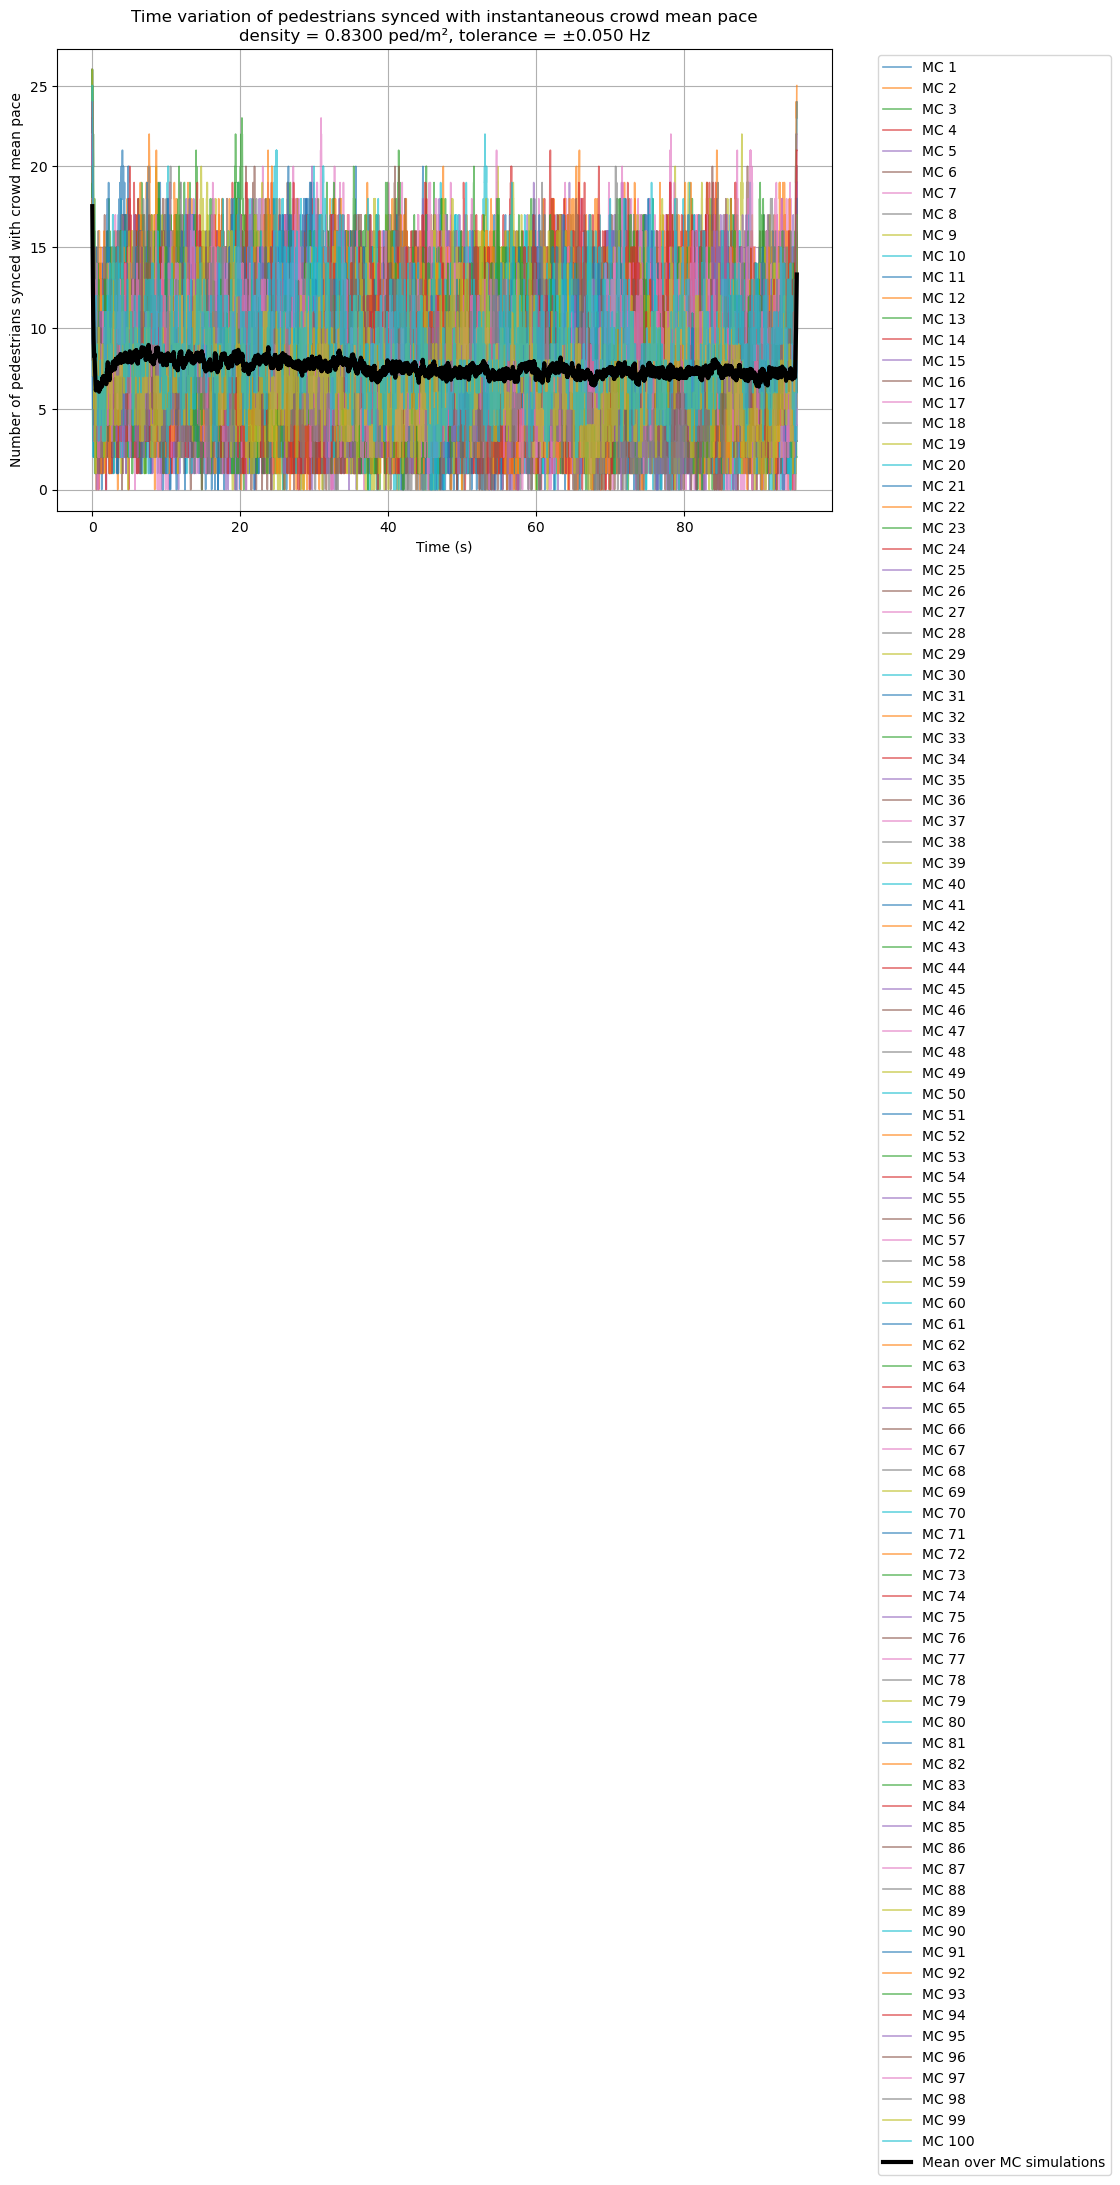

In [30]:
# ==================================================
# PLOT: TIME VARIATION OF NUMBER OF SYNCED PEDESTRIANS
# All 12 MC simulations in one graph
# ==================================================

plt.figure(figsize=(10, 6))

all_n_sync = []

for i, result in enumerate(results):

    time_velocity = result["time_velocity"]
    n_sync_time = result["n_sync_time"]

    all_n_sync.append(n_sync_time)

    plt.plot(
        time_velocity,
        n_sync_time,
        linewidth=1.2,
        alpha=0.65,
        label=f"MC {i + 1}"
    )

# Convert to array: shape = (NUM_SIMULATIONS, num_time_steps)
all_n_sync = np.asarray(all_n_sync)

# Mean time history across all MC simulations
mean_n_sync_time = np.nanmean(all_n_sync, axis=0)

plt.plot(
    time_velocity,
    mean_n_sync_time,
    color="black",
    linewidth=3.0,
    label="Mean over MC simulations"
)

plt.xlabel("Time (s)")
plt.ylabel("Number of pedestrians synced with crowd mean pace")
plt.title(
    "Time variation of pedestrians synced with instantaneous crowd mean pace\n"
    f"density = {actual_density:.4f} ped/m², tolerance = ±{pace_tolerance:.3f} Hz"
)

plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [8]:
# ==================================================
# MONTE CARLO PACE-SYNC ANALYSIS FOR MULTIPLE DENSITIES
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import pandas as pd
import multiprocessing as mp
import pickle

from pacesync import run_crowd_pace_sync_simulation


# ==================================================
# USER SETTINGS
# ==================================================

NUM_SIMULATIONS = 100
NUM_PROCESSES = 12

# Geometry
Length = 50.0
Width = 2.0

# Multiple pedestrian densities
densities = [0.6, 0.7, 0.8, 0.9]   # ped/m^2

# Social-force settings
meanvelocity = 1.45
stddev = 0.19
hht = 0.01

# Pedestrian interaction model
ped_model = "2D"

# Pace-sync analysis settings
pace_tolerance = 0.05
stride_mean = 0.75
stride_sd = 0.08
smooth_sec = 0.5

# Better to keep this False unless you need time histories
return_time_histories = True

# Reproducible MC seed generator
MASTER_SEED = 12345


# ==================================================
# MAIN
# ==================================================

if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    ctx = mp.get_context("spawn")

    all_summary_dfs = []
    all_mc_summary_rows = []

    # One multiprocessing pool reused for all densities
    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for density_index, density in enumerate(densities):

            print("\n" + "=" * 60)
            print(f"RUNNING DENSITY = {density:.4f} ped/m^2")
            print("=" * 60)

            # --------------------------------------------------
            # Convert density to pedestrian count
            # --------------------------------------------------
            total_peds_float = density * Length * Width
            total_peds_int = int(round(total_peds_float))
            total_peds_int = max(1, total_peds_int)

            Tocity = total_peds_int // 2
            Outcity = total_peds_int - Tocity

            actual_density = (Tocity + Outcity) / (Length * Width)

            print("\nDensity setup")
            print("-------------")
            print(f"Target density  = {density:.4f} ped/m^2")
            print(f"Actual density  = {actual_density:.4f} ped/m^2")
            print(f"Total peds      = {total_peds_int}")
            print(f"Tocity, Outcity = {Tocity}, {Outcity}")

            # --------------------------------------------------
            # Generate independent seeds for this density
            # --------------------------------------------------
            rng = np.random.default_rng(MASTER_SEED + density_index)
            seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

            # --------------------------------------------------
            # Build args list
            # --------------------------------------------------
            args_list = [
                (
                    int(seeds[i]),
                    Tocity,
                    Outcity,
                    Length,
                    Width,
                    meanvelocity,
                    stddev,
                    hht,
                    ped_model,
                    pace_tolerance,
                    stride_mean,
                    stride_sd,
                    smooth_sec,
                    return_time_histories
                )
                for i in range(NUM_SIMULATIONS)
            ]

            # --------------------------------------------------
            # Run MC simulations for this density
            # --------------------------------------------------
            results = pool.map(run_crowd_pace_sync_simulation, args_list)

            # --------------------------------------------------
            # Convert results to DataFrame
            # --------------------------------------------------
            summary_df = pd.DataFrame(results)

            summary_df.insert(0, "simulation_id", np.arange(1, len(summary_df) + 1))
            summary_df["target_density"] = density
            summary_df["actual_density"] = actual_density
            summary_df["num_pedestrians"] = total_peds_int
            summary_df["Tocity"] = Tocity
            summary_df["Outcity"] = Outcity

            print("\nFirst few MC results")
            print("--------------------")
            print(summary_df.head())

            # Store per-simulation results
            all_summary_dfs.append(summary_df)

            # --------------------------------------------------
            # MC summary over simulations for this density
            # --------------------------------------------------
            mc_summary = {
                "target_density": density,
                "actual_density": actual_density,
                "num_simulations": NUM_SIMULATIONS,
                "num_pedestrians": total_peds_int,
                "Tocity": Tocity,
                "Outcity": Outcity,

                "mean_of_mean_abs_velocity": summary_df["mean_abs_velocity"].mean(),
                "sd_of_mean_abs_velocity": summary_df["mean_abs_velocity"].std(ddof=1),

                "mean_of_sd_abs_velocity": summary_df["sd_abs_velocity"].mean(),
                "sd_of_sd_abs_velocity": summary_df["sd_abs_velocity"].std(ddof=1),

                "mean_of_overall_mean_pace": summary_df["overall_mean_pace"].mean(),
                "sd_of_overall_mean_pace": summary_df["overall_mean_pace"].std(ddof=1),

                "mean_of_overall_sd_pace": summary_df["overall_sd_pace"].mean(),
                "sd_of_overall_sd_pace": summary_df["overall_sd_pace"].std(ddof=1),

                "mean_of_mean_n_sync_over_time": summary_df["mean_n_sync_over_time"].mean(),
                "sd_of_mean_n_sync_over_time": summary_df["mean_n_sync_over_time"].std(ddof=1),

                "mean_of_sd_n_sync_over_time": summary_df["sd_n_sync_over_time"].mean(),
                "sd_of_sd_n_sync_over_time": summary_df["sd_n_sync_over_time"].std(ddof=1),

                "mean_of_mean_frac_sync_over_time": summary_df["mean_frac_sync_over_time"].mean(),
                "sd_of_mean_frac_sync_over_time": summary_df["mean_frac_sync_over_time"].std(ddof=1),

                "mean_of_mean_percent_sync_over_time": summary_df["mean_percent_sync_over_time"].mean(),
                "sd_of_mean_percent_sync_over_time": summary_df["mean_percent_sync_over_time"].std(ddof=1),
            }

            all_mc_summary_rows.append(mc_summary)

            mc_summary_df_current = pd.DataFrame([mc_summary])

            print("\nMC summary for this density")
            print("---------------------------")
            print(mc_summary_df_current.T)

            # --------------------------------------------------
            # Save results for this density separately
            # --------------------------------------------------
            save_name = f"pacesync_density{actual_density:.4f}_MC{NUM_SIMULATIONS}.pkl"

            save_obj = {
                "summary_df": summary_df,
                "mc_summary_df": mc_summary_df_current,
                "settings": {
                    "NUM_SIMULATIONS": NUM_SIMULATIONS,
                    "NUM_PROCESSES": NUM_PROCESSES,
                    "target_density": density,
                    "actual_density": actual_density,
                    "Tocity": Tocity,
                    "Outcity": Outcity,
                    "Length": Length,
                    "Width": Width,
                    "meanvelocity": meanvelocity,
                    "stddev": stddev,
                    "hht": hht,
                    "ped_model": ped_model,
                    "pace_tolerance": pace_tolerance,
                    "stride_mean": stride_mean,
                    "stride_sd": stride_sd,
                    "smooth_sec": smooth_sec,
                    "MASTER_SEED": MASTER_SEED,
                }
            }

            with open(save_name, "wb") as f:
                pickle.dump(save_obj, f, protocol=pickle.HIGHEST_PROTOCOL)

            print("\nSaved:")
            print(save_name)

    # ==================================================
    # COMBINE RESULTS FROM ALL DENSITIES
    # ==================================================

    all_summary_df = pd.concat(all_summary_dfs, ignore_index=True)
    all_mc_summary_df = pd.DataFrame(all_mc_summary_rows)

    print("\n" + "=" * 60)
    print("FINAL SUMMARY FOR ALL DENSITIES")
    print("=" * 60)
    print(all_mc_summary_df)

    # Save combined results
    combined_save_name = f"pacesync_all_densities2_MC{NUM_SIMULATIONS}.pkl"
    combined_csv_name = f"pacesync_all_densities2_summary_MC{NUM_SIMULATIONS}.csv"

    combined_save_obj = {
        "all_summary_df": all_summary_df,
        "all_mc_summary_df": all_mc_summary_df,
        "densities": densities,
        "settings": {
            "NUM_SIMULATIONS": NUM_SIMULATIONS,
            "NUM_PROCESSES": NUM_PROCESSES,
            "Length": Length,
            "Width": Width,
            "meanvelocity": meanvelocity,
            "stddev": stddev,
            "hht": hht,
            "ped_model": ped_model,
            "pace_tolerance": pace_tolerance,
            "stride_mean": stride_mean,
            "stride_sd": stride_sd,
            "smooth_sec": smooth_sec,
            "MASTER_SEED": MASTER_SEED,
        }
    }

    with open(combined_save_name, "wb") as f:
        pickle.dump(combined_save_obj, f, protocol=pickle.HIGHEST_PROTOCOL)

    all_mc_summary_df.to_csv(combined_csv_name, index=False)

    print("\nSaved combined results:")
    print(combined_save_name)
    print(combined_csv_name)


RUNNING DENSITY = 0.6000 ped/m^2

Density setup
-------------
Target density  = 0.6000 ped/m^2
Actual density  = 0.6000 ped/m^2
Total peds      = 60
Tocity, Outcity = 30, 30

First few MC results
--------------------
   simulation_id        seed  Tocity  Outcity  num_pedestrians  num_timesteps  \
0              1  1501552845      30       30               60           9519   
1              2   488200390      30       30               60           9519   
2              3  1693606510      30       30               60           9519   
3              4   680233354      30       30               60           9519   
4              5   438466540      30       30               60           9519   

   totalTimeSteps  Length  Width  meanvelocity_input  ...  \
0            9518    50.0    2.0                1.45  ...   
1            9518    50.0    2.0                1.45  ...   
2            9518    50.0    2.0                1.45  ...   
3            9518    50.0    2.0                1.4

Loading: pacesync_density0.1000_MC100.pkl
Loading: pacesync_density0.2000_MC100.pkl
Loading: pacesync_density0.5000_MC100.pkl
Loading: pacesync_density0.6000_MC100.pkl
Loading: pacesync_density0.7000_MC100.pkl
Loading: pacesync_density0.8000_MC100.pkl
Loading: pacesync_density0.9000_MC100.pkl
Loading: pacesync_density1.0000_MC100.pkl
Loading: pacesync_density1.5000_MC100.pkl
   target_density  actual_density  num_simulations  num_pedestrians  Tocity  \
0             0.1             0.1              100               10       5   
1             0.2             0.2              100               20      10   
2             0.5             0.5              100               50      25   
3             0.6             0.6              100               60      30   
4             0.7             0.7              100               70      35   
5             0.8             0.8              100               80      40   
6             0.9             0.9              100               90  

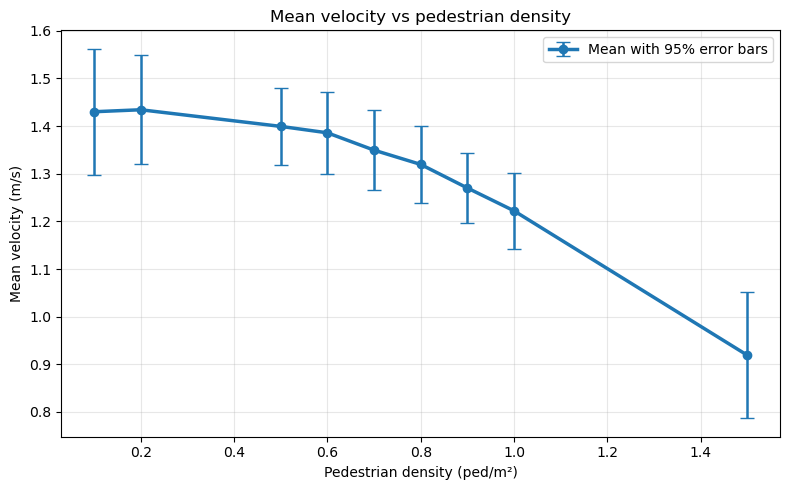


Velocity summary
   actual_density  mean_of_mean  sd_of_mean  num_simulations  mean_lower_95  \
0             0.1      1.430061    0.067377            100.0       1.298003   
1             0.2      1.434217    0.058602            100.0       1.319357   
2             0.5      1.399323    0.040821            100.0       1.319314   
3             0.6      1.385839    0.043940            100.0       1.299716   
4             0.7      1.349458    0.043034            100.0       1.265111   
5             0.8      1.319495    0.040847            100.0       1.239436   
6             0.9      1.270053    0.037466            100.0       1.196620   
7             1.0      1.222103    0.040881            100.0       1.141977   
8             1.5      0.919092    0.067465            100.0       0.786861   

   mean_upper_95  
0       1.562119  
1       1.549078  
2       1.479332  
3       1.471962  
4       1.433806  
5       1.399554  
6       1.343486  
7       1.302230  
8       1.051324  


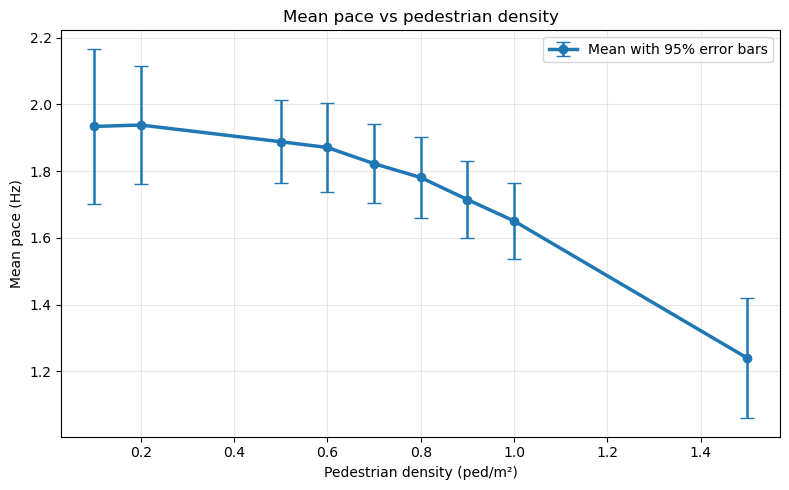


Pace summary
   actual_density  mean_of_mean  sd_of_mean  num_simulations  mean_lower_95  \
0             0.1      1.933970    0.118661            100.0       1.701395   
1             0.2      1.938178    0.090722            100.0       1.760362   
2             0.5      1.888199    0.063667            100.0       1.763412   
3             0.6      1.870930    0.068364            100.0       1.736936   
4             0.7      1.822394    0.060468            100.0       1.703877   
5             0.8      1.780995    0.062007            100.0       1.659461   
6             0.9      1.714834    0.058755            100.0       1.599675   
7             1.0      1.650870    0.058713            100.0       1.535791   
8             1.5      1.239917    0.091927            100.0       1.059739   

   mean_upper_95  
0       2.166546  
1       2.115993  
2       2.012986  
3       2.004924  
4       1.940912  
5       1.902528  
6       1.829994  
7       1.765948  
8       1.420094  


In [3]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import gc

# ==================================================
# LOAD ONLY SMALL MC SUMMARY FROM EACH PKL
# ==================================================

folder = Path(".")
pkl_files = sorted(folder.glob("pacesync_density*_MC100.pkl"))

summary_rows = []

for file in pkl_files:
    print("Loading:", file.name)

    with open(file, "rb") as f:
        data = pickle.load(f)

    # This is small: one row per density
    mc_summary_df = data["mc_summary_df"].copy()
    mc_summary_df["source_file"] = file.name

    summary_rows.append(mc_summary_df)

    # Delete large object before loading next file
    del data
    gc.collect()

all_mc_summary_df = pd.concat(summary_rows, ignore_index=True)
all_mc_summary_df = all_mc_summary_df.sort_values("actual_density").reset_index(drop=True)

print(all_mc_summary_df)

# ==================================================
# PLOT FUNCTION: MEAN WITH 95% ERROR BARS
# ==================================================

def plot_mean_and_spread_bands(
    summary,
    y_label,
    title,
    save_name=None,
    x_col="actual_density"
):
    x = summary[x_col].to_numpy()

    mean = summary["mean_of_mean"].to_numpy()

    mean_lower = summary["mean_lower_95"].to_numpy()
    mean_upper = summary["mean_upper_95"].to_numpy()

    # Convert lower/upper 95% limits into error-bar lengths
    yerr = np.vstack([
        mean - mean_lower,
        mean_upper - mean
    ])

    plt.figure(figsize=(8, 5))

    # Mean line with 95% error bars
    plt.errorbar(
        x,
        mean,
        yerr=yerr,
        marker="o",
        linewidth=2.5,
        capsize=5,
        elinewidth=1.8,
        label="Mean with 95% error bars"
    )

    plt.xlabel("Pedestrian density (ped/m²)")
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    #if save_name is not None:
        #plt.savefig(save_name, dpi=300, bbox_inches="tight")

    plt.show()

# ==================================================
# CREATE SUMMARY TABLES FROM SMALL MC SUMMARY FILES
# ==================================================

def make_summary_from_mc_summary(
    df,
    mean_col,
    sd_col,
    x_col="actual_density"
):
    out = pd.DataFrame({
        x_col: df[x_col].to_numpy(dtype=float),
        "mean_of_mean": df[mean_col].to_numpy(dtype=float),
        "sd_of_mean": df[sd_col].to_numpy(dtype=float),
        "num_simulations": df["num_simulations"].to_numpy(dtype=float),
    })

    # 95% error bar based on SD across MC simulations
    out["mean_lower_95"] = out["mean_of_mean"] - 1.96 * out["sd_of_mean"]
    out["mean_upper_95"] = out["mean_of_mean"] + 1.96 * out["sd_of_mean"]

    return out.sort_values(x_col).reset_index(drop=True)

# ==================================================
# 1. MEAN VELOCITY VS DENSITY
# ==================================================

velocity_summary = make_summary_from_mc_summary(
    all_mc_summary_df,
    mean_col="mean_of_mean_abs_velocity",
    sd_col="sd_of_mean_abs_velocity",
    x_col="actual_density"
)

plot_mean_and_spread_bands(
    velocity_summary,
    y_label="Mean velocity (m/s)",
    title="Mean velocity vs pedestrian density",
    save_name="mean_velocity_vs_density_errorbar.png"
)

print("\nVelocity summary")
print(velocity_summary)


# ==================================================
# 2. MEAN PACE VS DENSITY
# ==================================================

pace_summary = make_summary_from_mc_summary(
    all_mc_summary_df,
    mean_col="mean_of_overall_mean_pace",
    sd_col="sd_of_overall_mean_pace",
    x_col="actual_density"
)

plot_mean_and_spread_bands(
    pace_summary,
    y_label="Mean pace (Hz)",
    title="Mean pace vs pedestrian density",
    save_name="mean_pace_vs_density_errorbar.png"
)

print("\nPace summary")
print(pace_summary)

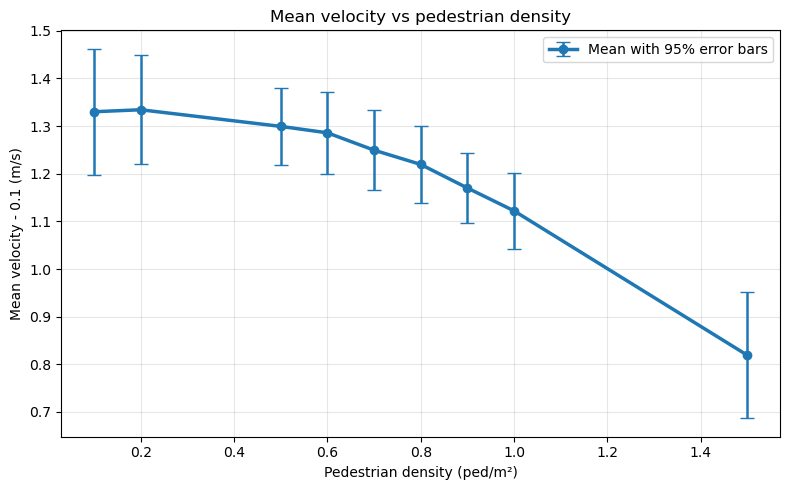


Shifted velocity summary
   actual_density  mean_of_mean  sd_of_mean  num_simulations  mean_lower_95  \
0             0.1      1.330061    0.067377            100.0       1.198003   
1             0.2      1.334217    0.058602            100.0       1.219357   
2             0.5      1.299323    0.040821            100.0       1.219314   
3             0.6      1.285839    0.043940            100.0       1.199716   
4             0.7      1.249458    0.043034            100.0       1.165111   
5             0.8      1.219495    0.040847            100.0       1.139436   
6             0.9      1.170053    0.037466            100.0       1.096620   
7             1.0      1.122103    0.040881            100.0       1.041977   
8             1.5      0.819092    0.067465            100.0       0.686861   

   mean_upper_95  
0       1.462119  
1       1.449078  
2       1.379332  
3       1.371962  
4       1.333806  
5       1.299554  
6       1.243486  
7       1.202230  
8       0.95

In [4]:
# ==================================================
# 1. MEAN VELOCITY VS DENSITY
# ==================================================

velocity_summary = make_summary_from_mc_summary(
    all_mc_summary_df,
    mean_col="mean_of_mean_abs_velocity",
    sd_col="sd_of_mean_abs_velocity",
    x_col="actual_density"
)

# Shift velocity values down by 0.1
velocity_summary_shifted = velocity_summary.copy()

velocity_shift = -0.1

velocity_summary_shifted["mean_of_mean"] += velocity_shift
velocity_summary_shifted["mean_lower_95"] += velocity_shift
velocity_summary_shifted["mean_upper_95"] += velocity_shift

plot_mean_and_spread_bands(
    velocity_summary_shifted,
    y_label="Mean velocity - 0.1 (m/s)",
    title="Mean velocity vs pedestrian density",
    save_name="mean_velocity_shifted_vs_density_errorbar.png"
)

print("\nShifted velocity summary")
print(velocity_summary_shifted)

   density_ped_per_m2  total_pedestrians_n  theoretical_n_sync  \
0                 0.1                 10.0            2.414953   
1                 0.2                 20.0            3.415260   
2                 0.5                 50.0            5.400000   
3                 1.0                100.0           18.500000   
4                 1.5                150.0           22.657780   

   theoretical_n_prime  theoretical_percent_sync  
0             0.024150                 24.149534  
1             0.034153                 17.076299  
2             0.054000                 10.800000  
3             0.185000                 18.500000  
4             0.226578                 15.105187  


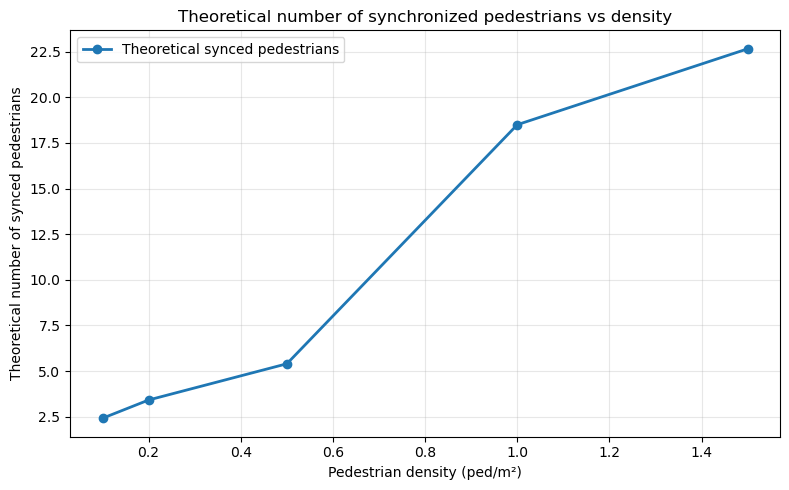

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# SETTINGS
# ==================================================

Length = 50.0
Width = 2.0
S = Length * Width

densities = np.array([0.1, 0.2, 0.5, 1.0, 1.5])

# Structural damping ratio
xi = 0.005   # 0.5%

# ==================================================
# THEORETICAL NUMBER OF SYNCED PEDESTRIANS
# ==================================================

n_total = densities * S

N_sync_theory = np.zeros_like(densities, dtype=float)

for i, density in enumerate(densities):

    n = n_total[i]

    if density < 1.0:
        # TC1 to TC3
        N_sync_theory[i] = 10.8 * np.sqrt(xi * n)
    else:
        # TC4 to TC5
        N_sync_theory[i] = 1.85 * np.sqrt(n)

n_prime_theory = N_sync_theory / S
percent_sync_theory = 100 * N_sync_theory / n_total

theory_df = pd.DataFrame({
    "density_ped_per_m2": densities,
    "total_pedestrians_n": n_total,
    "theoretical_n_sync": N_sync_theory,
    "theoretical_n_prime": n_prime_theory,
    "theoretical_percent_sync": percent_sync_theory,
})

print(theory_df)

plt.figure(figsize=(8, 5))

plt.plot(
    theory_df["density_ped_per_m2"],
    theory_df["theoretical_n_sync"],
    marker="o",
    linewidth=2,
    label="Theoretical synced pedestrians"
)

plt.xlabel("Pedestrian density (ped/m²)")
plt.ylabel("Theoretical number of synced pedestrians")
plt.title("Theoretical number of synchronized pedestrians vs density")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

   simulation_id  target_density  actual_density  num_pedestrians  \
0              1             0.1             0.1               10   
1              2             0.1             0.1               10   
2              3             0.1             0.1               10   
3              4             0.1             0.1               10   
4              5             0.1             0.1               10   

   overall_crowd_mean_pace  mean_n_sync_with_overall_mean_pace  \
0                 2.131533                            1.049065   
1                 2.105792                            1.218743   
2                 2.079207                            0.976571   
3                 1.921005                            0.174722   
4                 1.965521                            1.192477   

   sd_n_sync_with_overall_mean_pace  mean_percent_sync_with_overall_mean_pace  \
0                          0.917077                                 10.490649   
1                         

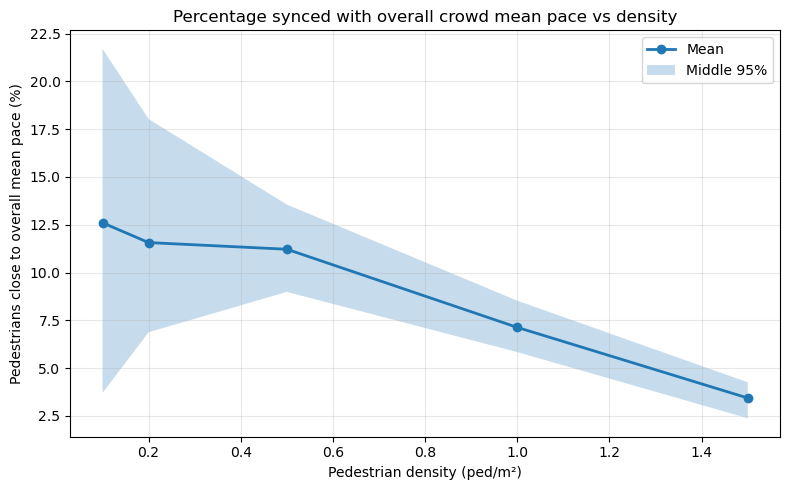

   actual_density       mean  lower_95   upper_95  num_simulations
0             0.1  12.601471  3.704271  21.701250              100
1             0.2  11.565849  6.875906  18.030416              100
2             0.5  11.217481  8.985590  13.554486              100
3             1.0   7.129909  5.837366   8.526684              100
4             1.5   3.436436  2.377828   4.257768              100


In [5]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# LOAD COMBINED RESULTS
# ==================================================

with open("pacesync_all_densities_MC100.pkl", "rb") as f:
    data = pickle.load(f)

all_summary_df = data["all_summary_df"]

pace_tolerance = 0.05  # Hz, same as your simulation setting


# ==================================================
# COMPUTE NUMBER SYNCED WITH OVERALL CROWD MEAN PACE
# ==================================================

new_rows = []

for idx, row in all_summary_df.iterrows():

    estimated_pace = np.asarray(row["estimated_pace"], dtype=float)

    # One fixed mean pace for the whole simulation
    overall_crowd_mean_pace = np.nanmean(estimated_pace)

    # Pedestrians close to the overall mean pace
    sync_mask = np.abs(estimated_pace - overall_crowd_mean_pace) <= pace_tolerance

    # Count synced pedestrians at each time step
    n_sync_time_overall_mean = np.nansum(sync_mask, axis=1)

    # Percentage synced at each time step
    num_pedestrians = row["num_pedestrians"]
    percent_sync_time_overall_mean = 100.0 * n_sync_time_overall_mean / num_pedestrians

    new_rows.append({
        "simulation_id": row["simulation_id"],
        "target_density": row["target_density"],
        "actual_density": row["actual_density"],
        "num_pedestrians": num_pedestrians,

        "overall_crowd_mean_pace": overall_crowd_mean_pace,

        "mean_n_sync_with_overall_mean_pace": np.nanmean(n_sync_time_overall_mean),
        "sd_n_sync_with_overall_mean_pace": np.nanstd(n_sync_time_overall_mean, ddof=1),

        "mean_percent_sync_with_overall_mean_pace": np.nanmean(percent_sync_time_overall_mean),
        "sd_percent_sync_with_overall_mean_pace": np.nanstd(percent_sync_time_overall_mean, ddof=1),
    })

sync_overall_mean_df = pd.DataFrame(new_rows)

print(sync_overall_mean_df.head())

def compute_mean_mid95(df, y_col, x_col="actual_density"):
    rows = []

    for density, sub in df.groupby(x_col):
        values = sub[y_col].dropna().to_numpy(dtype=float)

        rows.append({
            x_col: density,
            "mean": np.mean(values),
            "lower_95": np.percentile(values, 2.5),
            "upper_95": np.percentile(values, 97.5),
            "num_simulations": len(values),
        })

    return pd.DataFrame(rows).sort_values(x_col).reset_index(drop=True)


def plot_mean_mid95(summary, y_label, title, save_name=None, x_col="actual_density"):

    x = summary[x_col].to_numpy()
    mean = summary["mean"].to_numpy()
    lower = summary["lower_95"].to_numpy()
    upper = summary["upper_95"].to_numpy()

    plt.figure(figsize=(8, 5))

    plt.plot(x, mean, marker="o", linewidth=2, label="Mean")
    plt.fill_between(x, lower, upper, alpha=0.25, label="Middle 95%")

    plt.xlabel("Pedestrian density (ped/m²)")
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    if save_name is not None:
        plt.savefig(save_name, dpi=300, bbox_inches="tight")

    plt.show()

percent_sync_overall_summary = compute_mean_mid95(
    sync_overall_mean_df,
    y_col="mean_percent_sync_with_overall_mean_pace",
    x_col="actual_density"
)

plot_mean_mid95(
    percent_sync_overall_summary,
    y_label="Pedestrians close to overall mean pace (%)",
    title="Percentage synced with overall crowd mean pace vs density",
    save_name="percent_sync_with_overall_mean_pace_vs_density.png"
)

print(percent_sync_overall_summary)


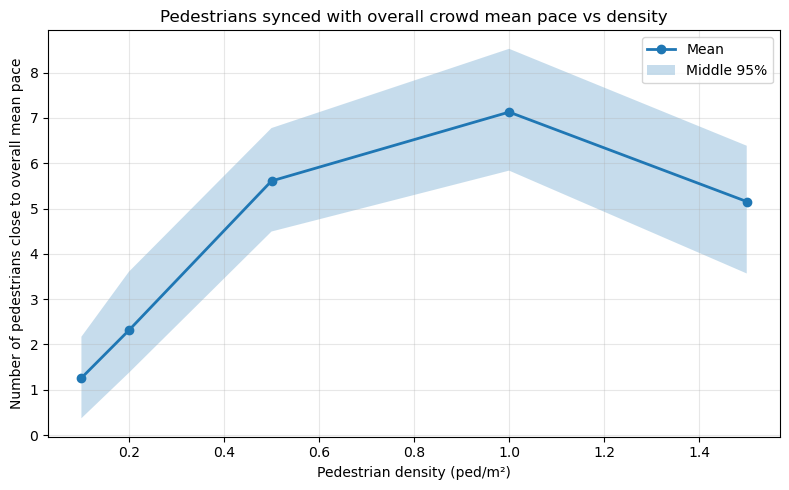

   actual_density      mean  lower_95  upper_95  num_simulations
0             0.1  1.260147  0.370427  2.170125              100
1             0.2  2.313170  1.375181  3.606083              100
2             0.5  5.608740  4.492795  6.777243              100
3             1.0  7.129909  5.837366  8.526684              100
4             1.5  5.154653  3.566742  6.386652              100


In [6]:
n_sync_overall_summary = compute_mean_mid95(
    sync_overall_mean_df,
    y_col="mean_n_sync_with_overall_mean_pace",
    x_col="actual_density"
)

plot_mean_mid95(
    n_sync_overall_summary,
    y_label="Number of pedestrians close to overall mean pace",
    title="Pedestrians synced with overall crowd mean pace vs density",
    save_name="n_sync_with_overall_mean_pace_vs_density.png"
)

print(n_sync_overall_summary)

   actual_density  total_pedestrians  theoretical_n_sync  \
0             0.1               10.0            2.414953   
1             0.2               20.0            3.415260   
2             0.5               50.0            5.400000   
3             1.0              100.0           18.500000   
4             1.5              150.0           22.657780   

   theoretical_percent_sync  derived_mean_n_sync  derived_lower_95  \
0                 24.149534             1.260147          0.370427   
1                 17.076299             2.313170          1.375181   
2                 10.800000             5.608740          4.492795   
3                 18.500000             7.129909          5.837366   
4                 15.105187             5.154653          3.566742   

   derived_upper_95  num_simulations  derived_percent_sync  \
0          2.170125              100             12.601471   
1          3.606083              100             11.565849   
2          6.777243             

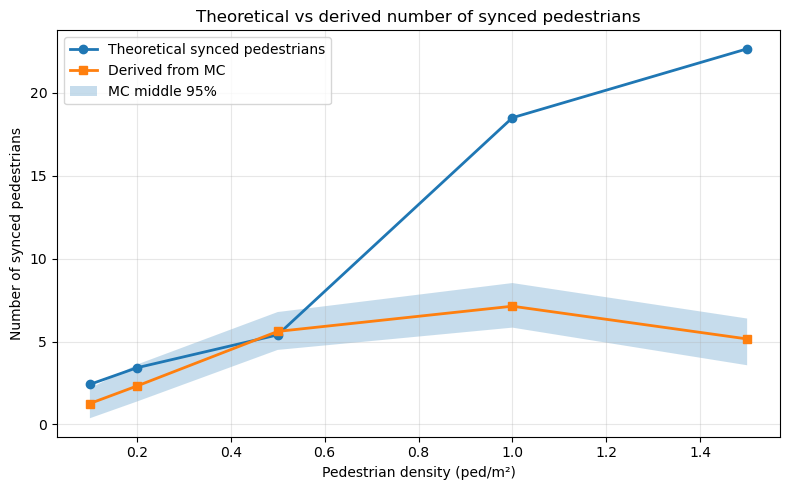

In [10]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# LOAD MC RESULTS
# ==================================================

with open("pacesync_all_densities_MC100.pkl", "rb") as f:
    data = pickle.load(f)

all_summary_df = data["all_summary_df"]


# ==================================================
# SETTINGS
# ==================================================

Length = 50.0
Width = 2.0
S = Length * Width

xi = 0.005
pace_tolerance = 0.05

# Choose one:
# "instantaneous_mean_pace" uses your existing mean_n_sync_over_time
# "overall_mean_pace" recomputes sync with one fixed overall crowd mean pace
DERIVED_MODE = "overall_mean_pace"


# ==================================================
# THEORETICAL NUMBER OF SYNCED PEDESTRIANS
# ==================================================

densities = np.array(sorted(all_summary_df["actual_density"].unique()))

n_total = densities * S
N_sync_theory = np.zeros_like(densities, dtype=float)

for i, density in enumerate(densities):

    n = n_total[i]

    if density < 1.0:
        # TC1 to TC3
        N_sync_theory[i] = 10.8 * np.sqrt(xi * n)
    else:
        # TC4 to TC5
        N_sync_theory[i] = 1.85 * np.sqrt(n)

theory_df = pd.DataFrame({
    "actual_density": densities,
    "total_pedestrians": n_total,
    "theoretical_n_sync": N_sync_theory,
    "theoretical_percent_sync": 100 * N_sync_theory / n_total
})


# ==================================================
# DERIVED/SIMULATED NUMBER OF SYNCED PEDESTRIANS
# ==================================================

derived_rows = []

for idx, row in all_summary_df.iterrows():

    density = row["actual_density"]
    num_pedestrians = row["num_pedestrians"]

    if DERIVED_MODE == "instantaneous_mean_pace":

        # This is already calculated in your pacesync.py
        mean_n_sync = row["mean_n_sync_over_time"]
        mean_percent_sync = row["mean_percent_sync_over_time"]

    elif DERIVED_MODE == "overall_mean_pace":

        # Recalculate using one fixed overall crowd mean pace
        estimated_pace = np.asarray(row["estimated_pace"], dtype=float)

        overall_mean_pace = np.nanmean(estimated_pace)

        sync_mask = np.abs(estimated_pace - overall_mean_pace) <= pace_tolerance

        n_sync_time = np.nansum(sync_mask, axis=1)

        percent_sync_time = 100.0 * n_sync_time / num_pedestrians

        mean_n_sync = np.nanmean(n_sync_time)
        mean_percent_sync = np.nanmean(percent_sync_time)

    else:
        raise ValueError("DERIVED_MODE must be 'instantaneous_mean_pace' or 'overall_mean_pace'.")

    derived_rows.append({
        "actual_density": density,
        "num_pedestrians": num_pedestrians,
        "derived_mean_n_sync": mean_n_sync,
        "derived_mean_percent_sync": mean_percent_sync
    })

derived_df = pd.DataFrame(derived_rows)


# ==================================================
# SUMMARY: MEAN + MIDDLE 95% ACROSS MC SIMULATIONS
# ==================================================

summary_rows = []

for density, sub in derived_df.groupby("actual_density"):

    values = sub["derived_mean_n_sync"].dropna().to_numpy(dtype=float)

    summary_rows.append({
        "actual_density": density,
        "derived_mean_n_sync": np.mean(values),
        "derived_lower_95": np.percentile(values, 2.5),
        "derived_upper_95": np.percentile(values, 97.5),
        "num_simulations": len(values)
    })

derived_summary_df = pd.DataFrame(summary_rows)
derived_summary_df = derived_summary_df.sort_values("actual_density").reset_index(drop=True)


# ==================================================
# COMBINE THEORY AND DERIVED RESULTS
# ==================================================

comparison_df = pd.merge(
    theory_df,
    derived_summary_df,
    on="actual_density",
    how="inner"
)

comparison_df["derived_percent_sync"] = (
    100 * comparison_df["derived_mean_n_sync"] / comparison_df["total_pedestrians"]
)

comparison_df["ratio_derived_to_theory"] = (
    comparison_df["derived_mean_n_sync"] / comparison_df["theoretical_n_sync"]
)

print(comparison_df)

# ==================================================
# PLOT: THEORETICAL VS DERIVED NUMBER OF SYNCED PEDESTRIANS
# ==================================================

plt.figure(figsize=(8, 5))

# Theoretical curve
plt.plot(
    comparison_df["actual_density"],
    comparison_df["theoretical_n_sync"],
    marker="o",
    linewidth=2,
    label="Theoretical synced pedestrians"
)

# Derived MC mean
plt.plot(
    comparison_df["actual_density"],
    comparison_df["derived_mean_n_sync"],
    marker="s",
    linewidth=2,
    label="Derived from MC"
)

# Middle 95% range of MC-derived result
plt.fill_between(
    comparison_df["actual_density"],
    comparison_df["derived_lower_95"],
    comparison_df["derived_upper_95"],
    alpha=0.25,
    label="MC middle 95%"
)

plt.xlabel("Pedestrian density (ped/m²)")
plt.ylabel("Number of synced pedestrians")
plt.title("Theoretical vs derived number of synced pedestrians")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("theoretical_vs_derived_n_sync.png", dpi=300, bbox_inches="tight")
plt.show()

Files found:
pacesync_density0.1000_MC100.pkl
pacesync_density0.2000_MC100.pkl
pacesync_density0.5000_MC100.pkl
pacesync_density0.6000_MC100.pkl
pacesync_density0.7000_MC100.pkl
pacesync_density0.8000_MC100.pkl
pacesync_density0.9000_MC100.pkl
pacesync_density1.0000_MC100.pkl
pacesync_density1.5000_MC100.pkl

Loaded combined DataFrame:
   simulation_id        seed  Tocity  Outcity  num_pedestrians  num_timesteps  \
0              1  1501552845       5        5               10           9519   
1              2   488200390       5        5               10           9519   
2              3  1693606510       5        5               10           9519   
3              4   680233354       5        5               10           9519   
4              5   438466540       5        5               10           9519   

   totalTimeSteps  Length  Width  meanvelocity_input  ...  \
0            9518    50.0    2.0                1.45  ...   
1            9518    50.0    2.0                1.45 

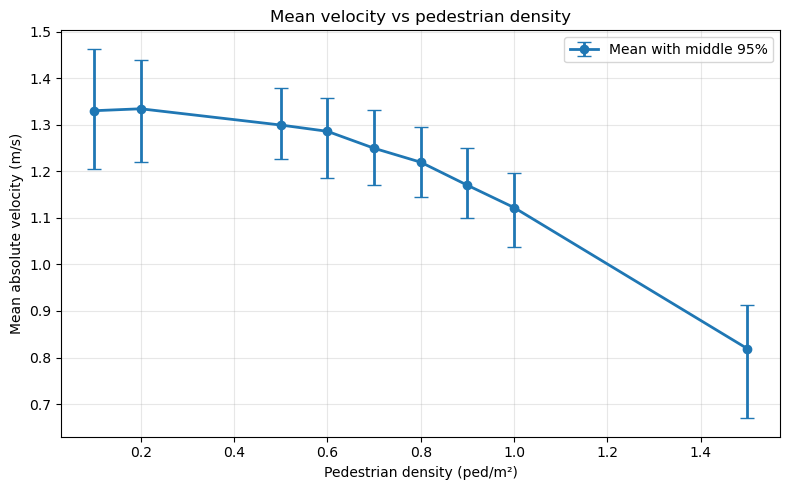


Mean velocity summary:
   actual_density      mean  lower_95  upper_95  err_lower  err_upper  \
0             0.1  1.430061  1.304292  1.563003   0.125769   0.132942   
1             0.2  1.434217  1.319102  1.539699   0.115116   0.105482   
2             0.5  1.399323  1.325696  1.479143   0.073627   0.079820   
3             0.6  1.385839  1.285575  1.456428   0.100264   0.070589   
4             0.7  1.349458  1.271064  1.431919   0.078394   0.082460   
5             0.8  1.319495  1.245378  1.394815   0.074117   0.075320   
6             0.9  1.270053  1.199965  1.349840   0.070088   0.079787   
7             1.0  1.222103  1.137072  1.296074   0.085032   0.073971   
8             1.5  0.919092  0.769647  1.011873   0.149445   0.092781   

   num_simulations  
0              100  
1              100  
2              100  
3              100  
4              100  
5              100  
6              100  
7              100  
8              100  


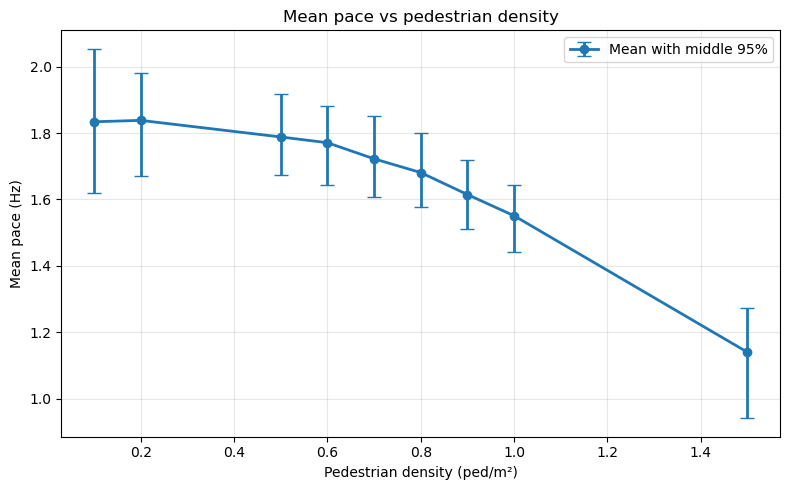


Mean pace summary:
   actual_density      mean  lower_95  upper_95  err_lower  err_upper  \
0             0.1  1.933970  1.719073  2.153804   0.214898   0.219834   
1             0.2  1.938178  1.770646  2.079673   0.167532   0.141495   
2             0.5  1.888199  1.773386  2.018982   0.114813   0.130783   
3             0.6  1.870930  1.744405  1.980127   0.126525   0.109197   
4             0.7  1.822394  1.705912  1.949881   0.116482   0.127487   
5             0.8  1.780995  1.678204  1.900471   0.102791   0.119476   
6             0.9  1.714834  1.612157  1.819927   0.102678   0.105093   
7             1.0  1.650870  1.540273  1.744472   0.110596   0.093602   
8             1.5  1.239917  1.040804  1.373842   0.199113   0.133926   

   num_simulations  
0              100  
1              100  
2              100  
3              100  
4              100  
5              100  
6              100  
7              100  
8              100  


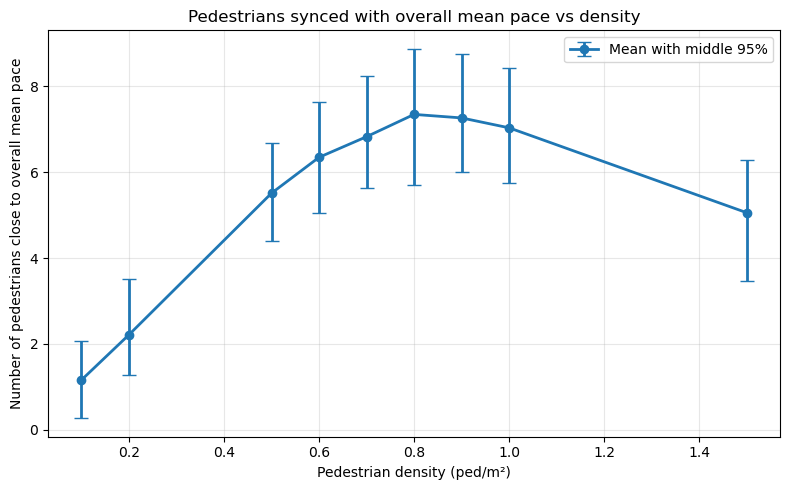


Number synced with overall mean pace summary:
   actual_density      mean  lower_95  upper_95  err_lower  err_upper  \
0             0.1  1.260147  0.370427  2.170125   0.889720   0.909978   
1             0.2  2.313170  1.375181  3.606083   0.937989   1.292913   
2             0.5  5.608740  4.492795  6.777243   1.115945   1.168503   
3             0.6  6.443654  5.141492  7.734169   1.302162   1.290515   
4             0.7  6.923660  5.738228  8.326928   1.185433   1.403267   
5             0.8  7.442683  5.793433  8.969392   1.649250   1.526709   
6             0.9  7.360725  6.097226  8.847683   1.263499   1.486958   
7             1.0  7.129909  5.837366  8.526684   1.292543   1.396775   
8             1.5  5.154653  3.566742  6.386652   1.587911   1.231998   

   num_simulations  
0              100  
1              100  
2              100  
3              100  
4              100  
5              100  
6              100  
7              100  
8              100  


In [6]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")   # change this if your pkl files are in another folder
file_pattern = "pacesync_density*_MC100.pkl"

pace_tolerance = 0.05   # Hz, same value you used in the simulations

# ==================================================
# LOAD ALL SEPARATE DENSITY PKL FILES
# ==================================================

pkl_files = sorted(folder.glob(file_pattern))

print("Files found:")
for f in pkl_files:
    print(f.name)

if len(pkl_files) == 0:
    raise FileNotFoundError("No pacesync_density*_MC100.pkl files found.")

all_summary_dfs = []

for file in pkl_files:
    with open(file, "rb") as f:
        data = pickle.load(f)

    summary_df = data["summary_df"].copy()
    summary_df["source_file"] = file.name

    all_summary_dfs.append(summary_df)

all_summary_df = pd.concat(all_summary_dfs, ignore_index=True)

print("\nLoaded combined DataFrame:")
print(all_summary_df.head())
print("\nColumns:")
print(all_summary_df.columns)

# ==================================================
# COMPUTE SYNC WITH OVERALL MEAN PACE
# ==================================================

if "estimated_pace" not in all_summary_df.columns:
    raise ValueError(
        "estimated_pace is not in the saved files. "
        "This means return_time_histories was probably False when you ran the simulations."
    )

sync_rows = []

for idx, row in all_summary_df.iterrows():

    estimated_pace = np.asarray(row["estimated_pace"], dtype=float)

    if estimated_pace.ndim != 2:
        raise ValueError(
            f"estimated_pace should be 2D: time x pedestrians. "
            f"Got shape {estimated_pace.shape} at row {idx}."
        )

    # One fixed crowd mean pace for this MC simulation
    overall_mean_pace = np.nanmean(estimated_pace)

    # Pedestrians close to the overall mean pace
    sync_mask = (
        np.isfinite(estimated_pace)
        & (np.abs(estimated_pace - overall_mean_pace) <= pace_tolerance)
    )

    # Count synced pedestrians at each time step
    n_sync_time_overall_mean = np.sum(sync_mask, axis=1)

    num_pedestrians = int(row["num_pedestrians"])

    percent_sync_time_overall_mean = (
        100.0 * n_sync_time_overall_mean / num_pedestrians
    )

    sync_rows.append({
        "source_file": row["source_file"],
        "simulation_id": row["simulation_id"],
        "actual_density": row["actual_density"],
        "target_density": row["target_density"],
        "num_pedestrians": num_pedestrians,

        "overall_mean_pace_recomputed": overall_mean_pace,

        "mean_n_sync_with_overall_mean_pace": np.nanmean(n_sync_time_overall_mean),
        "sd_n_sync_with_overall_mean_pace": np.nanstd(n_sync_time_overall_mean, ddof=1),

        "mean_percent_sync_with_overall_mean_pace": np.nanmean(percent_sync_time_overall_mean),
        "sd_percent_sync_with_overall_mean_pace": np.nanstd(percent_sync_time_overall_mean, ddof=1),
    })

sync_overall_df = pd.DataFrame(sync_rows)

print("\nSync with overall mean pace:")
print(sync_overall_df.head())

# ==================================================
# SUMMARY FUNCTION: MEAN + MIDDLE 95%
# ==================================================

def summarise_mean_mid95(df, y_col, x_col="actual_density"):
    rows = []

    for density, sub in df.groupby(x_col):
        values = sub[y_col].dropna().to_numpy(dtype=float)

        mean_val = np.mean(values)
        lower_95 = np.percentile(values, 2.5)
        upper_95 = np.percentile(values, 97.5)

        rows.append({
            x_col: density,
            "mean": mean_val,
            "lower_95": lower_95,
            "upper_95": upper_95,
            "err_lower": mean_val - lower_95,
            "err_upper": upper_95 - mean_val,
            "num_simulations": len(values),
        })

    return pd.DataFrame(rows).sort_values(x_col).reset_index(drop=True)


def plot_mean_mid95_errorbar(summary_df, y_label, title, save_name):
    x = summary_df["actual_density"].to_numpy()
    y = summary_df["mean"].to_numpy()-0.1
    yerr = np.vstack([
        summary_df["err_lower"].to_numpy(),
        summary_df["err_upper"].to_numpy()
    ])

    plt.figure(figsize=(8, 5))

    plt.errorbar(
        x,
        y,
        yerr=yerr,
        marker="o",
        linewidth=2,
        capsize=5,
        label="Mean with middle 95%"
    )

    plt.xlabel("Pedestrian density (ped/m²)")
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    #plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

    # ==================================================
# PLOT 1: MEAN VELOCITY VS DENSITY
# ==================================================

mean_velocity_summary = summarise_mean_mid95(
    all_summary_df,
    y_col="mean_abs_velocity",
    x_col="actual_density"
)

plot_mean_mid95_errorbar(
    mean_velocity_summary,
    y_label="Mean absolute velocity (m/s)",
    title="Mean velocity vs pedestrian density",
    save_name="mean_velocity_vs_density_errorbar.png"
)

print("\nMean velocity summary:")
print(mean_velocity_summary)

# ==================================================
# PLOT 2: MEAN PACE VS DENSITY
# ==================================================

mean_pace_summary = summarise_mean_mid95(
    all_summary_df,
    y_col="overall_mean_pace",
    x_col="actual_density"
)

plot_mean_mid95_errorbar(
    mean_pace_summary,
    y_label="Mean pace (Hz)",
    title="Mean pace vs pedestrian density",
    save_name="mean_pace_vs_density_errorbar.png"
)

print("\nMean pace summary:")
print(mean_pace_summary)

# ==================================================
# PLOT 3: NUMBER SYNCED WITH OVERALL MEAN PACE VS DENSITY
# ==================================================

n_sync_overall_summary = summarise_mean_mid95(
    sync_overall_df,
    y_col="mean_n_sync_with_overall_mean_pace",
    x_col="actual_density"
)

plot_mean_mid95_errorbar(
    n_sync_overall_summary,
    y_label="Number of pedestrians close to overall mean pace",
    title="Pedestrians synced with overall mean pace vs density",
    save_name="n_sync_with_overall_mean_pace_vs_density_errorbar.png"
)

print("\nNumber synced with overall mean pace summary:")
print(n_sync_overall_summary)


Pace translated from velocity summary:
   actual_density  mean_velocity_used  lower_95_velocity_used  \
0             0.1            1.330061                1.204292   
1             0.2            1.334217                1.219102   
2             0.5            1.299323                1.225696   
3             0.6            1.285839                1.185575   
4             0.7            1.249458                1.171064   
5             0.8            1.219495                1.145378   
6             0.9            1.170053                1.099965   
7             1.0            1.122103                1.037072   
8             1.5            0.819092                0.669647   

   upper_95_velocity_used  mean_pace  lower_95_pace  upper_95_pace  \
0                1.463003   1.907806       1.833881       1.979381   
1                1.439699   1.910122       1.843040       1.967111   
2                1.379143   1.890464       1.847074       1.934765   
3                1.356428   1

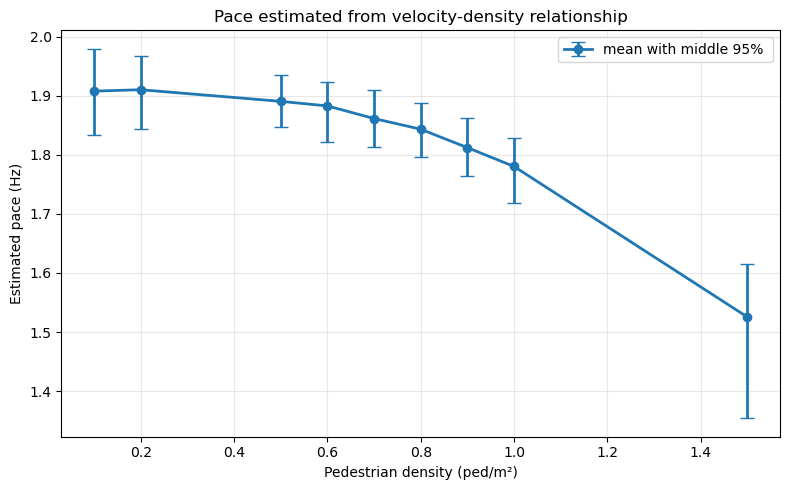

In [43]:
# ==================================================
# TRANSLATE VELOCITY SUMMARY INTO PACE SUMMARY
# n_m = 0.35 c_m^3 - 1.59 c_m^2 + 2.93 c_m
# ==================================================

def pace_from_velocity(c_m):
    return 0.35 * c_m**3 - 1.59 * c_m**2 + 2.93 * c_m


pace_from_velocity_summary = mean_velocity_summary.copy()

# Optional velocity shift
# Use this only if you really want to shift velocity by -0.1 before converting to pace
velocity_shift = -0.1

pace_from_velocity_summary["mean_velocity_used"] = (
    pace_from_velocity_summary["mean"] + velocity_shift
)

pace_from_velocity_summary["lower_95_velocity_used"] = (
    pace_from_velocity_summary["lower_95"] + velocity_shift
)

pace_from_velocity_summary["upper_95_velocity_used"] = (
    pace_from_velocity_summary["upper_95"] + velocity_shift
)

# Convert velocity statistics to pace statistics
pace_from_velocity_summary["mean_pace"] = pace_from_velocity(
    pace_from_velocity_summary["mean_velocity_used"]
)

pace_from_velocity_summary["lower_95_pace"] = pace_from_velocity(
    pace_from_velocity_summary["lower_95_velocity_used"]
)

pace_from_velocity_summary["upper_95_pace"] = pace_from_velocity(
    pace_from_velocity_summary["upper_95_velocity_used"]
)

# Error bars in pace units
pace_from_velocity_summary["err_lower_pace"] = (
    pace_from_velocity_summary["mean_pace"]
    - pace_from_velocity_summary["lower_95_pace"]
)

pace_from_velocity_summary["err_upper_pace"] = (
    pace_from_velocity_summary["upper_95_pace"]
    - pace_from_velocity_summary["mean_pace"]
)

print("\nPace translated from velocity summary:")
print(pace_from_velocity_summary[
    [
        "actual_density",
        "mean_velocity_used",
        "lower_95_velocity_used",
        "upper_95_velocity_used",
        "mean_pace",
        "lower_95_pace",
        "upper_95_pace",
        "err_lower_pace",
        "err_upper_pace",
        "num_simulations"
    ]
])

# ==================================================
# PLOT: TRANSLATED PACE VS DENSITY
# ==================================================

x = pace_from_velocity_summary["actual_density"].to_numpy()
y = pace_from_velocity_summary["mean_pace"].to_numpy()

yerr = np.vstack([
    pace_from_velocity_summary["err_lower_pace"].to_numpy(),
    pace_from_velocity_summary["err_upper_pace"].to_numpy()
])

plt.figure(figsize=(8, 5))

plt.errorbar(
    x,
    y,
    yerr=yerr,
    marker="o",
    linewidth=2,
    capsize=5,
    label="mean with middle 95% "
)

plt.xlabel("Pedestrian density (ped/m²)")
plt.ylabel("Estimated pace (Hz)")
plt.title("Pace estimated from velocity-density relationship")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

   actual_density  total_pedestrians  theoretical_n_sync  \
0             0.1               10.0            2.414953   
1             0.2               20.0            3.415260   
2             0.5               50.0            5.400000   
3             0.6               60.0            5.915404   
4             0.7               70.0            6.389366   
5             0.8               80.0            6.830520   
6             0.9               90.0            7.244860   
7             1.0              100.0           18.500000   
8             1.5              150.0           22.657780   

   theoretical_percent_sync  
0                 24.149534  
1                 17.076299  
2                 10.800000  
3                  9.859006  
4                  9.127666  
5                  8.538150  
6                  8.049845  
7                 18.500000  
8                 15.105187  
   actual_density  derived_mean_n_sync  derived_lower_95  derived_upper_95  \
0             0.1    

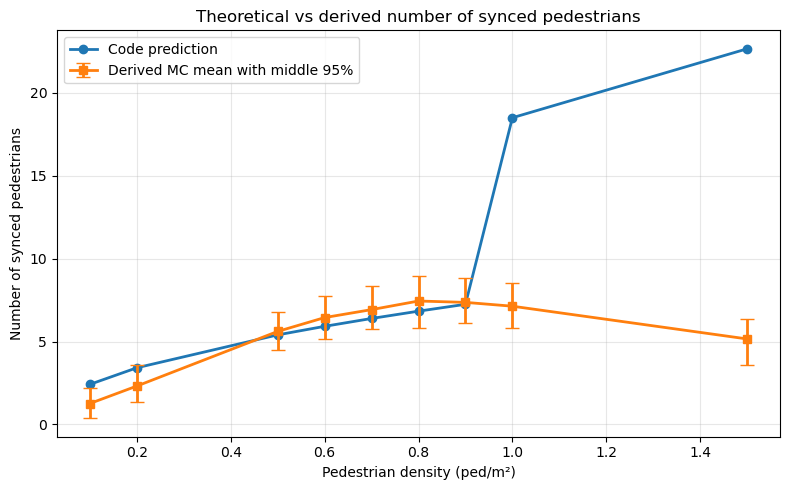

In [ ]:

# ==================================================
# THEORETICAL NUMBER FOR THE SAME DENSITIES
# ==================================================

Length = 50.0
Width = 2.0
S = Length * Width

xi = 0.005   # 0.5% damping

# Use the same densities already present in your derived summary
densities = n_sync_overall_summary["actual_density"].to_numpy(dtype=float)

n_total = densities * S

N_sync_theory = np.zeros_like(densities, dtype=float)

for i, density in enumerate(densities):

    n = n_total[i]

    if density < 1.0:
        # TC1 to TC3: density < 1 ped/m²
        N_sync_theory[i] = 10.8 * np.sqrt(xi * n)
    else:
        # TC4 to TC5: density >= 1 ped/m²
        N_sync_theory[i] = 1.85 * np.sqrt(n)

theory_same_density_df = pd.DataFrame({
    "actual_density": densities,
    "total_pedestrians": n_total,
    "theoretical_n_sync": N_sync_theory,
    "theoretical_percent_sync": 100 * N_sync_theory / n_total,
})

print(theory_same_density_df)

# ==================================================
# COMBINE DERIVED AND THEORETICAL RESULTS
# ==================================================

comparison_df = n_sync_overall_summary.merge(
    theory_same_density_df,
    on="actual_density",
    how="left"
)

comparison_df = comparison_df.rename(columns={
    "mean": "derived_mean_n_sync",
    "lower_95": "derived_lower_95",
    "upper_95": "derived_upper_95"
})

comparison_df["ratio_derived_to_theory"] = (
    comparison_df["derived_mean_n_sync"] / comparison_df["theoretical_n_sync"]
)

print(comparison_df)

# ==================================================
# PLOT: THEORETICAL VS DERIVED SYNCED PEDESTRIANS
# ==================================================

x = comparison_df["actual_density"].to_numpy()

y_derived = comparison_df["derived_mean_n_sync"].to_numpy()

yerr = np.vstack([
    comparison_df["err_lower"].to_numpy(),
    comparison_df["err_upper"].to_numpy()
])

plt.figure(figsize=(8, 5))

# Theoretical curve
plt.plot(
    x,
    comparison_df["theoretical_n_sync"],
    marker="o",
    linewidth=2,
    label="Code prediction"
)

# Derived MC result with 95% error bar
plt.errorbar(
    x,
    y_derived,
    yerr=yerr,
    marker="s",
    linewidth=2,
    capsize=5,
    label="Derived MC mean with middle 95%"
)

plt.xlabel("Pedestrian density (ped/m²)")
plt.ylabel("Number of synced pedestrians")
plt.title("Theoretical vs derived number of synced pedestrians")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("theoretical_vs_derived_n_sync_from_existing_summary.png", dpi=300, bbox_inches="tight")
plt.show()

   actual_density  total_pedestrians  theoretical_n_sync  \
0             0.1               10.0            5.915404   
1             0.2               20.0            8.365644   
2             0.5               50.0           13.227245   
3             0.6               60.0           14.489720   
4             0.7               70.0           15.650687   
5             0.8               80.0           16.731288   
6             0.9               90.0           17.746211   
7             1.0              100.0           18.500000   
8             1.5              150.0           22.657780   

   theoretical_percent_sync  
0                 59.154036  
1                 41.828220  
2                 26.454489  
3                 24.149534  
4                 22.358124  
5                 20.914110  
6                 19.718012  
7                 18.500000  
8                 15.105187  
   actual_density  derived_mean_n_sync  derived_lower_95  derived_upper_95  \
0             0.1    

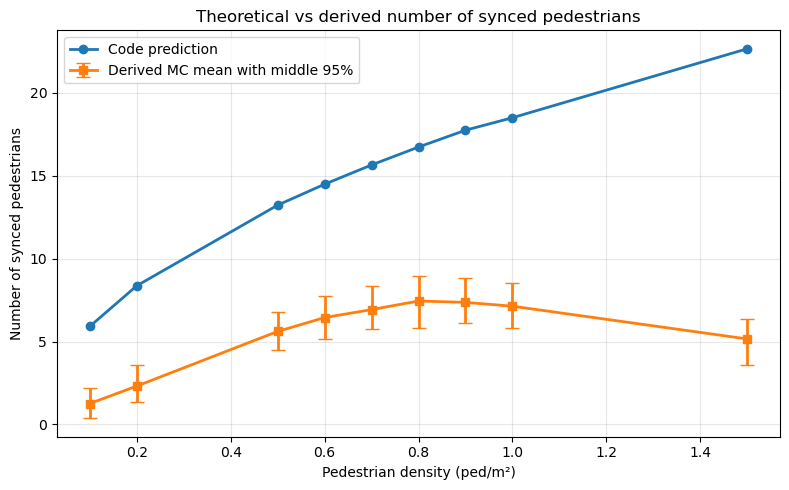

In [19]:

# ==================================================
# THEORETICAL NUMBER FOR THE SAME DENSITIES
# ==================================================

Length = 50.0
Width = 2.0
S = Length * Width

xi = 0.030  # 0.5% damping

# Use the same densities already present in your derived summary
densities = n_sync_overall_summary["actual_density"].to_numpy(dtype=float)

n_total = densities * S

N_sync_theory = np.zeros_like(densities, dtype=float)

for i, density in enumerate(densities):

    n = n_total[i]

    if density < 1.0:
        # TC1 to TC3: density < 1 ped/m²
        N_sync_theory[i] = 10.8 * np.sqrt(xi * n)
    else:
        # TC4 to TC5: density >= 1 ped/m²
        N_sync_theory[i] = 1.85 * np.sqrt(n)

theory_same_density_df = pd.DataFrame({
    "actual_density": densities,
    "total_pedestrians": n_total,
    "theoretical_n_sync": N_sync_theory,
    "theoretical_percent_sync": 100 * N_sync_theory / n_total,
})

print(theory_same_density_df)

# ==================================================
# COMBINE DERIVED AND THEORETICAL RESULTS
# ==================================================

comparison_df = n_sync_overall_summary.merge(
    theory_same_density_df,
    on="actual_density",
    how="left"
)

comparison_df = comparison_df.rename(columns={
    "mean": "derived_mean_n_sync",
    "lower_95": "derived_lower_95",
    "upper_95": "derived_upper_95"
})

comparison_df["ratio_derived_to_theory"] = (
    comparison_df["derived_mean_n_sync"] / comparison_df["theoretical_n_sync"]
)

print(comparison_df)

# ==================================================
# PLOT: THEORETICAL VS DERIVED SYNCED PEDESTRIANS
# ==================================================

x = comparison_df["actual_density"].to_numpy()

y_derived = comparison_df["derived_mean_n_sync"].to_numpy()

yerr = np.vstack([
    comparison_df["err_lower"].to_numpy(),
    comparison_df["err_upper"].to_numpy()
])

plt.figure(figsize=(8, 5))

# Theoretical curve
plt.plot(
    x,
    comparison_df["theoretical_n_sync"],
    marker="o",
    linewidth=2,
    label="Code prediction"
)

# Derived MC result with 95% error bar
plt.errorbar(
    x,
    y_derived,
    yerr=yerr,
    marker="s",
    linewidth=2,
    capsize=5,
    label="Derived MC mean with middle 95%"
)

plt.xlabel("Pedestrian density (ped/m²)")
plt.ylabel("Number of synced pedestrians")
plt.title("Theoretical vs derived number of synced pedestrians")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

#plt.savefig("theoretical_vs_derived_n_sync_from_existing_summary.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
# ==================================================
# ANIMATED GIF FOR SELECTED DENSITY + SELECTED MC RUN
# Motion + velocity + pace + synced pedestrian count
# ==================================================

from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ==================================================
# USER SELECTION
# ==================================================

selected_density = 1.0000     # change this, e.g. 0.6000, 0.7000, 0.9000, 1.0000
selected_run_number = 1       # 1 = first MC simulation, 2 = second, etc.

NUM_SIMULATIONS = 100

frame_stride = 25
fps = 20

# ==================================================
# FIND AND LOAD THE DENSITY FILE
# ==================================================

pkl_file = Path(f"pacesync_density{selected_density:.4f}_MC{NUM_SIMULATIONS}.pkl")

if not pkl_file.exists():
    raise FileNotFoundError(
        f"Could not find {pkl_file}. "
        "Check the density value and file name."
    )

print("Loading:", pkl_file)

with open(pkl_file, "rb") as f:
    obj = pickle.load(f)

summary_df = obj["summary_df"]
settings = obj["settings"]

print("Available columns:")
print(summary_df.columns)

# ==================================================
# SELECT ONE MC RUN
# ==================================================

if "simulation_id" in summary_df.columns:
    row_df = summary_df[summary_df["simulation_id"] == selected_run_number]

    if row_df.empty:
        raise ValueError(f"Run number {selected_run_number} not found.")

    row = row_df.iloc[0]

else:
    row = summary_df.iloc[selected_run_number - 1]

# ==================================================
# EXTRACT TIME HISTORIES
# ==================================================

time_velocity = np.asarray(row["time_velocity"])
speed_x_smooth = np.asarray(row["speed_x_smooth"])
estimated_pace = np.asarray(row["estimated_pace"])
mean_pace_time = np.asarray(row["mean_pace_time"])
n_sync_time = np.asarray(row["n_sync_time"])
frac_sync_time = np.asarray(row["frac_sync_time"])

x_coords = np.asarray(row["x_coords"])
y_coords = np.asarray(row["y_coords"])

length = float(settings["Length"])
width = float(settings["Width"])

pace_tolerance = float(row["pace_tolerance"]) if "pace_tolerance" in row else float(settings["pace_tolerance"])

num_pedestrians = estimated_pace.shape[1]
mean_speed_time = np.nanmean(speed_x_smooth, axis=1)

actual_density = float(row["actual_density"])
num_pedestrians_saved = int(row["num_pedestrians"])

print("\nSelected case")
print("-------------")
print(f"Density              = {actual_density:.4f} ped/m²")
print(f"MC run number         = {selected_run_number}")
print(f"Number of pedestrians = {num_pedestrians_saved}")
print(f"Mean n_sync over time = {np.nanmean(n_sync_time):.3f}")
print(f"SD n_sync over time   = {np.nanstd(n_sync_time, ddof=1):.3f}")

# ==================================================
# ANIMATION SETTINGS
# ==================================================

frames = np.arange(0, len(time_velocity), frame_stride)

gif_name = (
    f"pedestrian_motion_velocity_pace_nsync_"
    f"density{actual_density:.4f}_MC{selected_run_number}.gif"
)

# Axis limits
v_min, v_max = np.nanpercentile(speed_x_smooth, [1, 99])
p_min, p_max = np.nanpercentile(estimated_pace, [1, 99])

v_pad = 0.15 * (v_max - v_min)
p_pad = 0.15 * (p_max - p_min)

n_sync_max = max(1, np.nanmax(n_sync_time))

# ==================================================
# FIGURE SETUP: 4 PANELS
# ==================================================

fig, axes = plt.subplots(
    4, 1,
    figsize=(10, 8),
    gridspec_kw={"height_ratios": [1.0, 1.0, 1.0, 0.8]}
)

ax_motion, ax_vel, ax_pace, ax_sync = axes

# ==================================================
# PANEL 1: PEDESTRIAN MOTION
# ==================================================

scatter = ax_motion.scatter([], [], s=35)

ax_motion.set_xlim(0, length)
ax_motion.set_ylim(0, width)
ax_motion.set_xlabel("Bridge length x (m)")
ax_motion.set_ylabel("Bridge width y (m)")
ax_motion.set_title(
    f"Pedestrian motion on bridge | Density = {actual_density:.2f} ped/m² | MC {selected_run_number}"
)
ax_motion.grid(True)

time_text = ax_motion.text(
    0.02, 0.88,
    "",
    transform=ax_motion.transAxes,
    fontsize=11,
    bbox=dict(facecolor="white", alpha=0.8)
)

# ==================================================
# PANEL 2: VELOCITY TIME HISTORIES
# ==================================================

vel_lines = []
for j in range(num_pedestrians):
    line, = ax_vel.plot([], [], linewidth=0.8, alpha=0.35)
    vel_lines.append(line)

mean_vel_line, = ax_vel.plot(
    [],
    [],
    color="black",
    linewidth=2.5,
    label="Mean velocity"
)

current_vel_line = ax_vel.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.5
)

ax_vel.set_xlim(time_velocity[0], time_velocity[-1])
ax_vel.set_ylim(v_min - v_pad, v_max + v_pad)
ax_vel.set_xlabel("Time (s)")
ax_vel.set_ylabel("Velocity")
ax_vel.set_title("Absolute velocity variation with time for all pedestrians")
ax_vel.grid(True)
ax_vel.legend(loc="upper right")

# ==================================================
# PANEL 3: PACE TIME HISTORIES
# ==================================================

pace_lines = []
for j in range(num_pedestrians):
    line, = ax_pace.plot([], [], linewidth=0.8, alpha=0.30)
    pace_lines.append(line)

mean_pace_line, = ax_pace.plot(
    [],
    [],
    color="black",
    linewidth=2.5,
    label="Mean crowd pace"
)

upper_tol_line, = ax_pace.plot(
    [],
    [],
    color="black",
    linestyle=":",
    linewidth=1.5,
    label=f"Mean ± {pace_tolerance:.3f} Hz"
)

lower_tol_line, = ax_pace.plot(
    [],
    [],
    color="black",
    linestyle=":",
    linewidth=1.5
)

current_pace_line = ax_pace.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.5
)

ax_pace.set_xlim(time_velocity[0], time_velocity[-1])
ax_pace.set_ylim(p_min - p_pad, p_max + p_pad)
ax_pace.set_xlabel("Time (s)")
ax_pace.set_ylabel("Pace")
ax_pace.set_title("Pace variation with time for all pedestrians")
ax_pace.grid(True)
ax_pace.legend(loc="upper right")

# ==================================================
# PANEL 4: SYNCED PEDESTRIAN COUNT
# ==================================================

n_sync_line, = ax_sync.plot(
    [],
    [],
    color="black",
    linewidth=2.5,
    label=r"$n_{\mathrm{sync}}(t)$"
)

n_sync_marker, = ax_sync.plot(
    [],
    [],
    marker="o",
    color="black",
    markersize=6
)

current_sync_line = ax_sync.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.5
)

ax_sync.set_xlim(time_velocity[0], time_velocity[-1])
ax_sync.set_ylim(0, n_sync_max * 1.15)
ax_sync.set_xlabel("Time (s)")
ax_sync.set_ylabel("Synced pedestrians")
ax_sync.set_title("Time variation of synced pedestrian count")
ax_sync.grid(True)
ax_sync.legend(loc="upper right")

plt.tight_layout()

# ==================================================
# UPDATE FUNCTION
# ==================================================

def update(frame_id):

    k = frames[frame_id]
    current_time = time_velocity[k]
    tt = time_velocity[:k + 1]

    # Position uses k+1 because velocity/pace arrays are from np.diff
    pos_k = min(k + 1, x_coords.shape[0] - 1)

    scatter.set_offsets(
        np.column_stack((x_coords[pos_k, :], y_coords[pos_k, :]))
    )

    time_text.set_text(f"t = {current_time:.2f} s")

    # Velocity
    for j in range(num_pedestrians):
        vel_lines[j].set_data(tt, speed_x_smooth[:k + 1, j])

    mean_vel_line.set_data(tt, mean_speed_time[:k + 1])
    current_vel_line.set_xdata([current_time, current_time])

    # Pace
    for j in range(num_pedestrians):
        pace_lines[j].set_data(tt, estimated_pace[:k + 1, j])

    mean_pace_line.set_data(tt, mean_pace_time[:k + 1])
    upper_tol_line.set_data(tt, mean_pace_time[:k + 1] + pace_tolerance)
    lower_tol_line.set_data(tt, mean_pace_time[:k + 1] - pace_tolerance)
    current_pace_line.set_xdata([current_time, current_time])

    # Synced count
    n_sync_line.set_data(tt, n_sync_time[:k + 1])
    n_sync_marker.set_data([current_time], [n_sync_time[k]])
    current_sync_line.set_xdata([current_time, current_time])

    return (
        [scatter, time_text,
         mean_vel_line, current_vel_line,
         mean_pace_line, upper_tol_line, lower_tol_line, current_pace_line,
         n_sync_line, n_sync_marker, current_sync_line]
        + vel_lines
        + pace_lines
    )

# ==================================================
# CREATE AND SAVE GIF
# ==================================================

anim = FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=1000 / fps,
    blit=False
)

anim.save(
    gif_name,
    writer=PillowWriter(fps=fps)
)

plt.close(fig)

print(f"\nSaved GIF as: {gif_name}")

Loading: pacesync_density1.0000_MC100.pkl
Available columns:
Index(['simulation_id', 'seed', 'Tocity', 'Outcity', 'num_pedestrians',
       'num_timesteps', 'totalTimeSteps', 'Length', 'Width',
       'meanvelocity_input', 'stddev_input', 'hht', 'ped_model',
       'pace_tolerance', 'stride_mean', 'stride_sd', 'smooth_sec',
       'mean_abs_velocity', 'sd_abs_velocity', 'overall_mean_pace',
       'overall_sd_pace', 'mean_n_sync_over_time', 'sd_n_sync_over_time',
       'mean_frac_sync_over_time', 'sd_frac_sync_over_time',
       'mean_percent_sync_over_time', 'time_velocity', 'speed_x_smooth',
       'mean_speed_time', 'estimated_pace', 'mean_pace_time', 'n_sync_time',
       'frac_sync_time', 'x_coords', 'y_coords', 'target_density',
       'actual_density'],
      dtype='object')

Selected case
-------------
Density              = 1.0000 ped/m²
MC run number         = 1
Number of pedestrians = 100
Mean n_sync over time = 6.748
SD n_sync over time   = 2.936

Saved GIF as: pedestrian_

In [51]:
# ==================================================
# MONTE CARLO PACE-SYNC ANALYSIS FOR MULTIPLE DENSITIES
# ONE-DIRECTION FLOW, INDIVIDUAL SUMMARY FILES ONLY
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import pandas as pd
import multiprocessing as mp
import pickle
import gc

from pacesync import run_crowd_pace_sync_simulation


# ==================================================
# USER SETTINGS
# ==================================================

NUM_SIMULATIONS = 96
NUM_PROCESSES = 12

# Geometry
Length = 50.0
Width = 2.0

# Multiple pedestrian densities
densities = [0.6, 0.7, 0.8, 0.9]   # ped/m^2

# Social-force settings
meanvelocity = 1.45
stddev = 0.19
hht = 0.01

# Pedestrian interaction model
ped_model = "Diamond_asym"

# Pace-sync analysis settings
pace_tolerance = 0.05
stride_mean = 0.75
stride_sd = 0.08
smooth_sec = 0.5

# IMPORTANT: no time histories returned or saved
return_time_histories = False

# Reproducible MC seed generator
MASTER_SEED = 12345


# ==================================================
# HELPER FUNCTION
# ==================================================

def mean_and_sd(x):
    x = pd.to_numeric(x, errors="coerce")
    return x.mean(), x.std(ddof=1)


# ==================================================
# MAIN
# ==================================================

if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    ctx = mp.get_context("spawn")

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for density_index, density in enumerate(densities):

            print("\n" + "=" * 70)
            print(f"RUNNING DENSITY = {density:.4f} ped/m^2")
            print("=" * 70)

            # --------------------------------------------------
            # Convert density to pedestrian count
            # --------------------------------------------------
            total_peds_float = density * Length * Width
            total_peds_int = int(round(total_peds_float))
            total_peds_int = max(1, total_peds_int)

            # --------------------------------------------------
            # ONE-DIRECTION FLOW ONLY
            # --------------------------------------------------
            Tocity = total_peds_int
            Outcity = 0

            actual_density = (Tocity + Outcity) / (Length * Width)

            print("\nDensity setup")
            print("-------------")
            print(f"Target density  = {density:.4f} ped/m^2")
            print(f"Actual density  = {actual_density:.4f} ped/m^2")
            print(f"Total peds      = {total_peds_int}")
            print(f"Tocity          = {Tocity}")
            print(f"Outcity         = {Outcity}")

            # --------------------------------------------------
            # Independent seeds for this density
            # --------------------------------------------------
            rng = np.random.default_rng(MASTER_SEED + density_index)
            seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

            # --------------------------------------------------
            # Build multiprocessing argument list
            # --------------------------------------------------
            args_list = [
                (
                    int(seeds[i]),
                    Tocity,
                    Outcity,
                    Length,
                    Width,
                    meanvelocity,
                    stddev,
                    hht,
                    ped_model,
                    pace_tolerance,
                    stride_mean,
                    stride_sd,
                    smooth_sec,
                    return_time_histories
                )
                for i in range(NUM_SIMULATIONS)
            ]

            # --------------------------------------------------
            # Run MC simulations
            # --------------------------------------------------
            results = pool.map(run_crowd_pace_sync_simulation, args_list)

            # --------------------------------------------------
            # Keep only scalar values needed for summary
            # This DataFrame is temporary and is NOT saved
            # --------------------------------------------------
            per_sim_keys = [
                "mean_abs_velocity",
                "sd_abs_velocity",
                "overall_mean_pace",
                "overall_sd_pace",
                "mean_n_sync_over_time",
                "sd_n_sync_over_time",
            ]

            summary_df = pd.DataFrame([
                {key: result.get(key, np.nan) for key in per_sim_keys}
                for result in results
            ])

            print("\nFirst few scalar MC results")
            print("---------------------------")
            print(summary_df.head())

            # --------------------------------------------------
            # Calculate density-level MC summary
            # --------------------------------------------------
            mean_of_mean_abs_velocity, sd_of_mean_abs_velocity = mean_and_sd(
                summary_df["mean_abs_velocity"]
            )

            mean_of_sd_abs_velocity, sd_of_sd_abs_velocity = mean_and_sd(
                summary_df["sd_abs_velocity"]
            )

            mean_of_overall_mean_pace, sd_of_overall_mean_pace = mean_and_sd(
                summary_df["overall_mean_pace"]
            )

            mean_of_overall_sd_pace, sd_of_overall_sd_pace = mean_and_sd(
                summary_df["overall_sd_pace"]
            )

            mean_of_mean_n_sync_over_time, sd_of_mean_n_sync_over_time = mean_and_sd(
                summary_df["mean_n_sync_over_time"]
            )

            mean_of_sd_n_sync_over_time, sd_of_sd_n_sync_over_time = mean_and_sd(
                summary_df["sd_n_sync_over_time"]
            )

            mc_summary = {
                "target_density": density,
                "actual_density": actual_density,
                "num_simulations": NUM_SIMULATIONS,
                "num_pedestrians": total_peds_int,
                "Tocity": Tocity,
                "Outcity": Outcity,

                "mean_of_mean_abs_velocity": mean_of_mean_abs_velocity,
                "sd_of_mean_abs_velocity": sd_of_mean_abs_velocity,

                "mean_of_sd_abs_velocity": mean_of_sd_abs_velocity,
                "sd_of_sd_abs_velocity": sd_of_sd_abs_velocity,

                "mean_of_overall_mean_pace": mean_of_overall_mean_pace,
                "sd_of_overall_mean_pace": sd_of_overall_mean_pace,

                "mean_of_overall_sd_pace": mean_of_overall_sd_pace,
                "sd_of_overall_sd_pace": sd_of_overall_sd_pace,

                "mean_of_mean_n_sync_over_time": mean_of_mean_n_sync_over_time,
                "sd_of_mean_n_sync_over_time": sd_of_mean_n_sync_over_time,

                "mean_of_sd_n_sync_over_time": mean_of_sd_n_sync_over_time,
                "sd_of_sd_n_sync_over_time": sd_of_sd_n_sync_over_time,
            }

            mc_summary_df_current = pd.DataFrame([mc_summary])

            print("\nMC summary for this density")
            print("---------------------------")
            print(mc_summary_df_current.T)

            # --------------------------------------------------
            # Save ONLY individual density-level summary
            # --------------------------------------------------
            save_name = (
                f"pacesync_density{actual_density:.4f}"
                f"_one_direction_summary_only_MC{NUM_SIMULATIONS}.pkl"
            )

            save_obj = {
                "mc_summary_df": mc_summary_df_current,
                "settings": {
                    "NUM_SIMULATIONS": NUM_SIMULATIONS,
                    "NUM_PROCESSES": NUM_PROCESSES,
                    "target_density": density,
                    "actual_density": actual_density,
                    "num_pedestrians": total_peds_int,
                    "Tocity": Tocity,
                    "Outcity": Outcity,
                    "Length": Length,
                    "Width": Width,
                    "meanvelocity": meanvelocity,
                    "stddev": stddev,
                    "hht": hht,
                    "ped_model": ped_model,
                    "pace_tolerance": pace_tolerance,
                    "stride_mean": stride_mean,
                    "stride_sd": stride_sd,
                    "smooth_sec": smooth_sec,
                    "return_time_histories": return_time_histories,
                    "MASTER_SEED": MASTER_SEED,
                }
            }

            with open(save_name, "wb") as f:
                pickle.dump(save_obj, f, protocol=pickle.HIGHEST_PROTOCOL)

            print("\nSaved individual density summary only:")
            print(save_name)

            # --------------------------------------------------
            # Clear memory before next density
            # --------------------------------------------------
            del results
            del summary_df
            del mc_summary_df_current
            del save_obj
            gc.collect()

    print("\n" + "=" * 70)
    print("DONE: Only individual density summary .pkl files were saved.")
    print("=" * 70)


RUNNING DENSITY = 0.6000 ped/m^2

Density setup
-------------
Target density  = 0.6000 ped/m^2
Actual density  = 0.6000 ped/m^2
Total peds      = 60
Tocity          = 60
Outcity         = 0

First few scalar MC results
---------------------------
   mean_abs_velocity  sd_abs_velocity  overall_mean_pace  overall_sd_pace  \
0           1.415190         0.234451           1.895267         0.380665   
1           1.563346         0.155365           2.081740         0.288199   
2           1.448279         0.197845           1.951437         0.354727   
3           1.473788         0.231607           1.989163         0.388088   
4           1.414521         0.194837           1.921436         0.352897   

   mean_n_sync_over_time  sd_n_sync_over_time  
0               7.537613             2.414929  
1              10.036667             2.678888  
2               9.321181             3.033717  
3               7.277895             2.556701  
4               7.567451             2.305596  



Files found:
   pacesync_density0.1000_one_direction_summary_only_MC96.pkl
   pacesync_density0.2000_one_direction_summary_only_MC96.pkl
   pacesync_density0.5000_one_direction_summary_only_MC96.pkl
   pacesync_density0.6000_one_direction_summary_only_MC96.pkl
   pacesync_density0.7000_one_direction_summary_only_MC96.pkl
   pacesync_density0.8000_one_direction_summary_only_MC96.pkl
   pacesync_density0.9000_one_direction_summary_only_MC96.pkl
   pacesync_density1.0000_one_direction_summary_only_MC96.pkl
   pacesync_density1.5000_one_direction_summary_only_MC96.pkl
Loading: pacesync_density0.1000_one_direction_summary_only_MC96.pkl
Loading: pacesync_density0.2000_one_direction_summary_only_MC96.pkl
Loading: pacesync_density0.5000_one_direction_summary_only_MC96.pkl
Loading: pacesync_density0.6000_one_direction_summary_only_MC96.pkl
Loading: pacesync_density0.7000_one_direction_summary_only_MC96.pkl
Loading: pacesync_density0.8000_one_direction_summary_only_MC96.pkl
Loading: pacesync_den

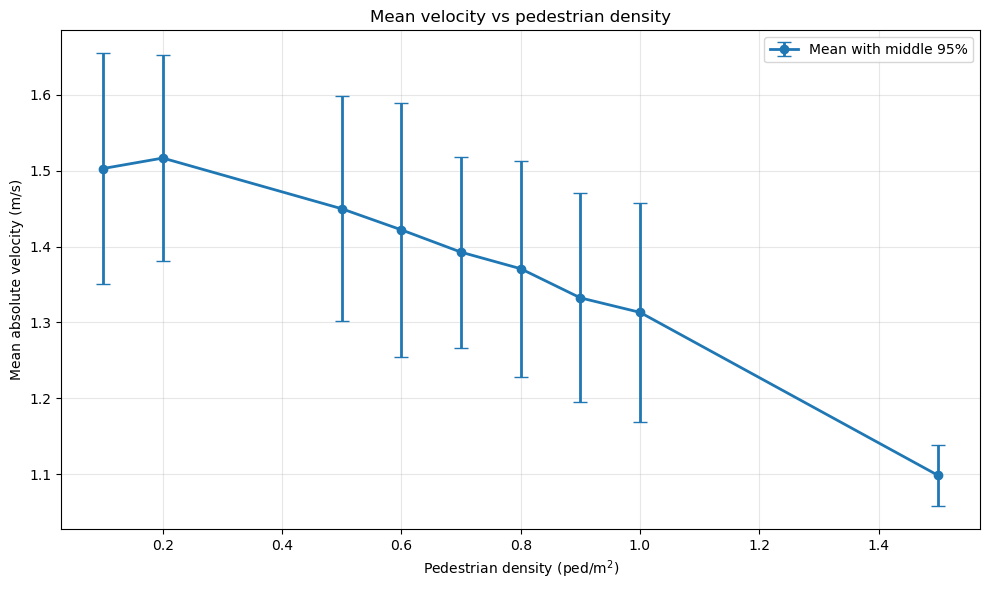

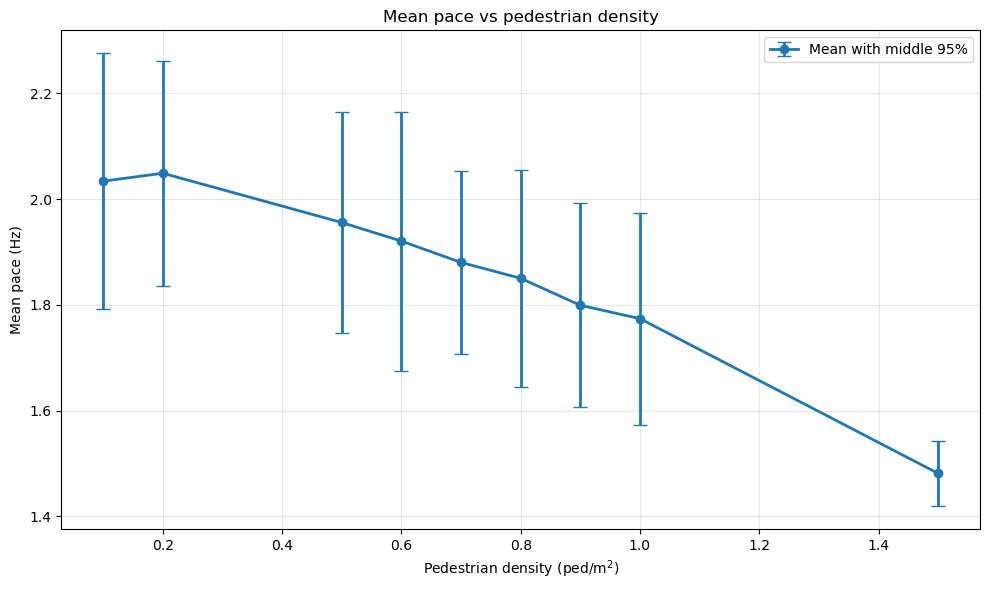

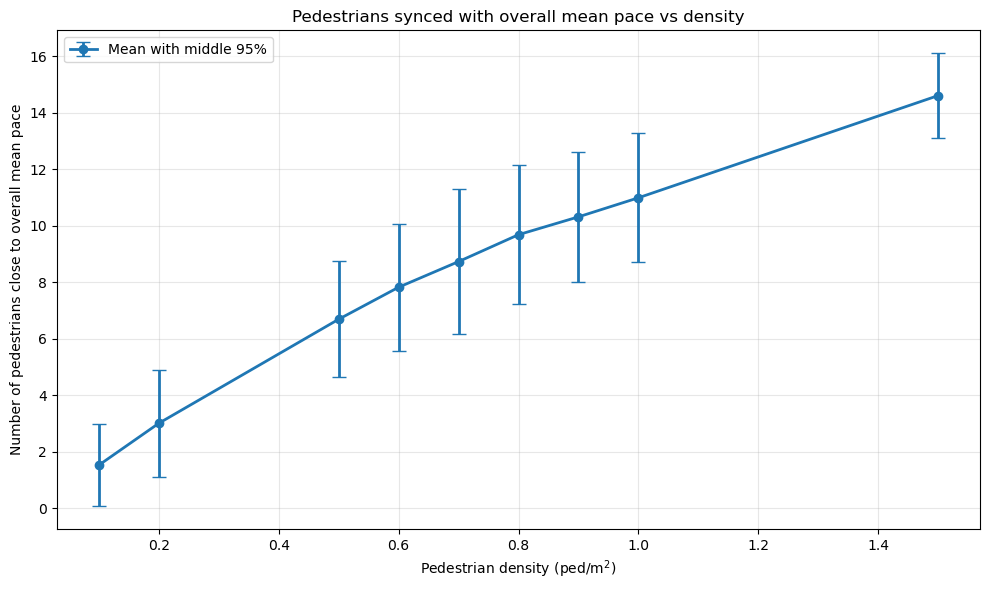

In [57]:
import pickle
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")   # change this if the pkl files are in another folder

NUM_SIMULATIONS_TO_LOAD = 96

pkl_files = sorted(
    folder.glob(
        f"pacesync_density*_one_direction_summary_only_MC{NUM_SIMULATIONS_TO_LOAD}.pkl"
    )
)

if len(pkl_files) == 0:
    raise FileNotFoundError("No matching summary-only pkl files found.")

print("Files found:")
for file in pkl_files:
    print("  ", file.name)


# ==================================================
# LOAD INDIVIDUAL SUMMARY FILES ONLY
# ==================================================

summary_rows = []

for file in pkl_files:
    print("Loading:", file.name)

    with open(file, "rb") as f:
        data = pickle.load(f)

    df = data["mc_summary_df"].copy()
    df["source_file"] = file.name

    summary_rows.append(df)

    del data
    gc.collect()

all_summary_df = pd.concat(summary_rows, ignore_index=True)

all_summary_df = all_summary_df.sort_values("actual_density").reset_index(drop=True)

print("\nLoaded summary:")
print(all_summary_df[[
    "actual_density",
    "num_pedestrians",
    "mean_of_mean_abs_velocity",
    "sd_of_mean_abs_velocity",
    "mean_of_overall_mean_pace",
    "sd_of_overall_mean_pace",
    "mean_of_mean_n_sync_over_time",
    "sd_of_mean_n_sync_over_time",
]])


# ==================================================
# PLOT FUNCTION
# ==================================================

def plot_mean_with_middle_95(
    df,
    mean_col,
    sd_col,
    title,
    ylabel,
    save_name=None
):
    x = pd.to_numeric(df["actual_density"], errors="coerce").to_numpy()
    y = pd.to_numeric(df[mean_col], errors="coerce").to_numpy()
    sd = pd.to_numeric(df[sd_col], errors="coerce").to_numpy()

    # Approximate middle 95% range from saved mean and SD
    # Since only summary statistics were saved, exact percentiles cannot be recovered.
    yerr = 1.96 * sd

    plt.figure(figsize=(10, 6))

    plt.errorbar(
        x,
        y,
        yerr=yerr,
        marker="o",
        linewidth=2,
        capsize=5,
        label="Mean with middle 95%"
    )

    plt.xlabel("Pedestrian density (ped/m$^2$)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    if save_name is not None:
        plt.savefig(save_name, dpi=300, bbox_inches="tight")

    plt.show()


# ==================================================
# PLOT 1: MEAN VELOCITY VS DENSITY
# ==================================================

plot_mean_with_middle_95(
    all_summary_df,
    mean_col="mean_of_mean_abs_velocity",
    sd_col="sd_of_mean_abs_velocity",
    title="Mean velocity vs pedestrian density",
    ylabel="Mean absolute velocity (m/s)",
    save_name="mean_velocity_vs_density.png"
)


# ==================================================
# PLOT 2: MEAN PACE VS DENSITY
# ==================================================

plot_mean_with_middle_95(
    all_summary_df,
    mean_col="mean_of_overall_mean_pace",
    sd_col="sd_of_overall_mean_pace",
    title="Mean pace vs pedestrian density",
    ylabel="Mean pace (Hz)",
    save_name="mean_pace_vs_density.png"
)


# ==================================================
# PLOT 3: NUMBER OF SYNCED PEDESTRIANS VS DENSITY
# ==================================================

plot_mean_with_middle_95(
    all_summary_df,
    mean_col="mean_of_mean_n_sync_over_time",
    sd_col="sd_of_mean_n_sync_over_time",
    title="Pedestrians synced with overall mean pace vs density",
    ylabel="Number of pedestrians close to overall mean pace",
    save_name="synced_pedestrians_vs_density.png"
)

Loading OLD: pacesync_density0.1000_MC100.pkl
Loading OLD: pacesync_density0.2000_MC100.pkl
Loading OLD: pacesync_density0.5000_MC100.pkl
Loading OLD: pacesync_density0.6000_MC100.pkl
Loading OLD: pacesync_density0.7000_MC100.pkl
Loading OLD: pacesync_density0.8000_MC100.pkl
Loading OLD: pacesync_density0.9000_MC100.pkl
Loading OLD: pacesync_density1.0000_MC100.pkl
Loading OLD: pacesync_density1.5000_MC100.pkl

OLD DATA:
       label                       source_file  actual_density  \
0  Old MC100  pacesync_density0.1000_MC100.pkl             0.1   
1  Old MC100  pacesync_density0.2000_MC100.pkl             0.2   
2  Old MC100  pacesync_density0.5000_MC100.pkl             0.5   
3  Old MC100  pacesync_density0.6000_MC100.pkl             0.6   
4  Old MC100  pacesync_density0.7000_MC100.pkl             0.7   
5  Old MC100  pacesync_density0.8000_MC100.pkl             0.8   
6  Old MC100  pacesync_density0.9000_MC100.pkl             0.9   
7  Old MC100  pacesync_density1.0000_MC100.pkl 

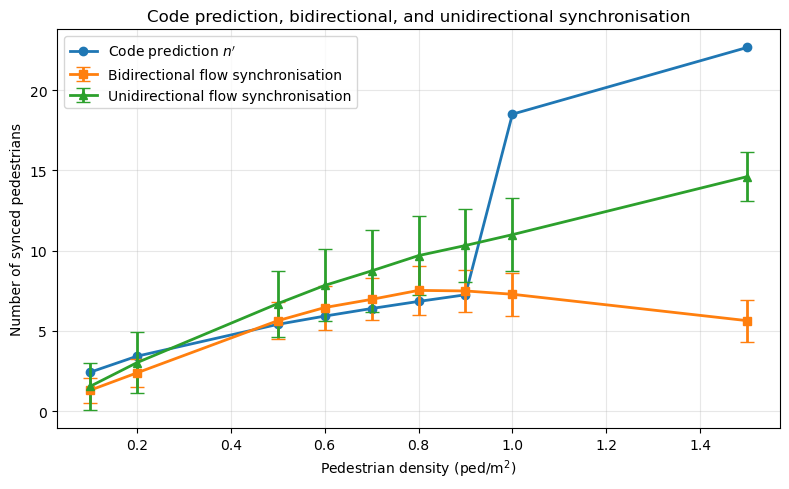

In [52]:
# ==================================================
# OLD DATA + NEW DATA + THEORETICAL CURVE
# 3 LINES IN ONE GRAPH
# ==================================================

import pickle
import re
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

Length = 50.0
Width = 2.0
S = Length * Width


# If you want 0.5%, use xi = 0.005.
xi = 0.005


# ==================================================
# HELPER: GET DENSITY FROM FILE NAME
# ==================================================

def density_from_filename(file_name):
    match = re.search(r"density([0-9]+(?:\.[0-9]+)?)", file_name)
    if match:
        return float(match.group(1))
    return np.nan


# ==================================================
# HELPER: EXTRACT N_SYNC SUMMARY FROM ONE PKL FILE
# ==================================================

def extract_n_sync_summary(file, label):
    with open(file, "rb") as f:
        data = pickle.load(f)

    density_from_name = density_from_filename(file.name)

    # --------------------------------------------------
    # Case 1: New summary-only files
    # They contain mc_summary_df
    # --------------------------------------------------
    if isinstance(data, dict) and "mc_summary_df" in data:

        df = data["mc_summary_df"].copy()
        row = df.iloc[0]

        actual_density = row.get("actual_density", density_from_name)
        num_pedestrians = row.get("num_pedestrians", actual_density * S)

        mean_n_sync = row.get("mean_of_mean_n_sync_over_time", np.nan)
        sd_n_sync = row.get("sd_of_mean_n_sync_over_time", np.nan)

        return {
            "label": label,
            "source_file": file.name,
            "actual_density": float(actual_density),
            "num_pedestrians": float(num_pedestrians),
            "mean_n_sync": float(mean_n_sync),
            "sd_n_sync": float(sd_n_sync),
        }

    # --------------------------------------------------
    # Case 2: Old files may contain per-simulation results
    # Try to reconstruct mean_n_sync from results
    # --------------------------------------------------
    possible_result_keys = [
        "results",
        "results_all",
        "simulation_results",
        "all_results",
    ]

    results = None

    if isinstance(data, dict):
        for key in possible_result_keys:
            if key in data:
                results = data[key]
                break

    vals = []

    if results is not None:

        if isinstance(results, dict):
            iterable_results = results.values()
        else:
            iterable_results = results

        for result in iterable_results:

            if not isinstance(result, dict):
                continue

            # Best case: scalar already saved
            if "mean_n_sync_over_time" in result:
                vals.append(result["mean_n_sync_over_time"])

            # If time history of synced pedestrians was saved
            elif "n_sync_time" in result:
                vals.append(np.nanmean(result["n_sync_time"]))

            elif "n_sync_over_time" in result:
                vals.append(np.nanmean(result["n_sync_over_time"]))

    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]

    if len(vals) > 0:

        if isinstance(data, dict):
            settings = data.get("settings", {})
        else:
            settings = {}

        actual_density = settings.get("actual_density", density_from_name)
        num_pedestrians = settings.get("num_pedestrians", actual_density * S)

        return {
            "label": label,
            "source_file": file.name,
            "actual_density": float(actual_density),
            "num_pedestrians": float(num_pedestrians),
            "mean_n_sync": float(np.nanmean(vals)),
            "sd_n_sync": float(np.nanstd(vals, ddof=1)) if len(vals) > 1 else np.nan,
        }

    # --------------------------------------------------
    # If structure is unknown
    # --------------------------------------------------
    if isinstance(data, dict):
        print(f"\nCould not read {file.name}")
        print("Available keys:", list(data.keys()))
    else:
        print(f"\nCould not read {file.name}")
        print("Data type:", type(data))

    return None


# ==================================================
# LOAD OLD MC100 FILES
# ==================================================

old_files = sorted(folder.glob("pacesync_density*_MC100.pkl"))

old_rows = []

for file in old_files:
    # Skip any file that is actually one-direction summary-only
    if "one_direction_summary_only" in file.name:
        continue

    print("Loading OLD:", file.name)
    row = extract_n_sync_summary(file, label="Old MC100")
    if row is not None:
        old_rows.append(row)

    gc.collect()

old_df = pd.DataFrame(old_rows)

if len(old_df) > 0:
    old_df = old_df.sort_values("actual_density").reset_index(drop=True)

print("\nOLD DATA:")
print(old_df)


# ==================================================
# LOAD NEW ONE-DIRECTION MC96 FILES
# ==================================================

new_files = sorted(folder.glob("pacesync_density*_one_direction_summary_only_MC96.pkl"))

new_rows = []

for file in new_files:
    print("Loading NEW:", file.name)
    row = extract_n_sync_summary(file, label="New one-direction MC96")
    if row is not None:
        new_rows.append(row)

    gc.collect()

new_df = pd.DataFrame(new_rows)

if len(new_df) > 0:
    new_df = new_df.sort_values("actual_density").reset_index(drop=True)

print("\nNEW DATA:")
print(new_df)


# ==================================================
# THEORETICAL CURVE FOR SAME DENSITIES
# ==================================================

all_densities = np.unique(
    np.concatenate([
        old_df["actual_density"].to_numpy(dtype=float) if len(old_df) > 0 else np.array([]),
        new_df["actual_density"].to_numpy(dtype=float) if len(new_df) > 0 else np.array([]),
    ])
)

all_densities = np.sort(all_densities)

n_total = all_densities * S

N_sync_theory = np.zeros_like(all_densities, dtype=float)

for i, density in enumerate(all_densities):

    n = n_total[i]

    if density < 1.0:
        N_sync_theory[i] = 10.8 * np.sqrt(xi * n)
    else:
        N_sync_theory[i] = 1.85 * np.sqrt(n)

theory_df = pd.DataFrame({
    "actual_density": all_densities,
    "total_pedestrians": n_total,
    "theoretical_n_sync": N_sync_theory,
    "theoretical_percent_sync": 100 * N_sync_theory / n_total,
})

print("\nTHEORY:")
print(theory_df)


# ==================================================
# ADD ERROR BAR COLUMNS
# ==================================================

def add_error_bar_columns(df):
    df = df.copy()

    # Approximate middle 95% using mean ± 1.96 SD
    # If exact percentiles were not saved, this is the best we can do.
    df["err_lower"] = 1.96 * df["sd_n_sync"]
    df["err_upper"] = 1.96 * df["sd_n_sync"]

    df["lower_95"] = df["mean_n_sync"] - df["err_lower"]
    df["upper_95"] = df["mean_n_sync"] + df["err_upper"]

    # Number of pedestrians cannot be negative
    df["lower_95"] = df["lower_95"].clip(lower=0)

    df["err_lower"] = df["mean_n_sync"] - df["lower_95"]
    df["err_upper"] = df["upper_95"] - df["mean_n_sync"]

    return df


if len(old_df) > 0:
    old_df = add_error_bar_columns(old_df)

if len(new_df) > 0:
    new_df = add_error_bar_columns(new_df)


# ==================================================
# PLOT: CODE n' + BIDIRECTIONAL + UNIDIRECTIONAL
# ==================================================

plt.figure(figsize=(8, 5))

# --------------------------------------------------
# 1. Code prediction n'
# --------------------------------------------------
plt.plot(
    theory_df["actual_density"],
    theory_df["theoretical_n_sync"],
    marker="o",
    linewidth=2,
    color="tab:blue",
    label="Code prediction $n'$"
)

# --------------------------------------------------
# 2. Bidirectional synchronisation MC100
# old_df = old bidirectional-flow files
# --------------------------------------------------
if len(old_df) > 0:

    old_yerr = np.vstack([
        old_df["err_lower"].to_numpy(dtype=float),
        old_df["err_upper"].to_numpy(dtype=float)
    ])

    plt.errorbar(
        old_df["actual_density"],
        old_df["mean_n_sync"],
        yerr=old_yerr,
        marker="s",
        linewidth=2,
        capsize=5,
        color="tab:orange",
        label="Bidirectional flow synchronisation"
    )

# --------------------------------------------------
# 3. Unidirectional synchronisation MC96
# new_df = new one-direction files
# --------------------------------------------------
if len(new_df) > 0:

    new_yerr = np.vstack([
        new_df["err_lower"].to_numpy(dtype=float),
        new_df["err_upper"].to_numpy(dtype=float)
    ])

    plt.errorbar(
        new_df["actual_density"],
        new_df["mean_n_sync"],
        yerr=new_yerr,
        marker="^",
        linewidth=2,
        capsize=5,
        color="tab:green",
        label="Unidirectional flow synchronisation"
    )

plt.xlabel("Pedestrian density (ped/m$^2$)")
plt.ylabel("Number of synced pedestrians")
plt.title("Code prediction, bidirectional, and unidirectional synchronisation")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# plt.savefig("code_bidirectional_unidirectional_n_sync_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

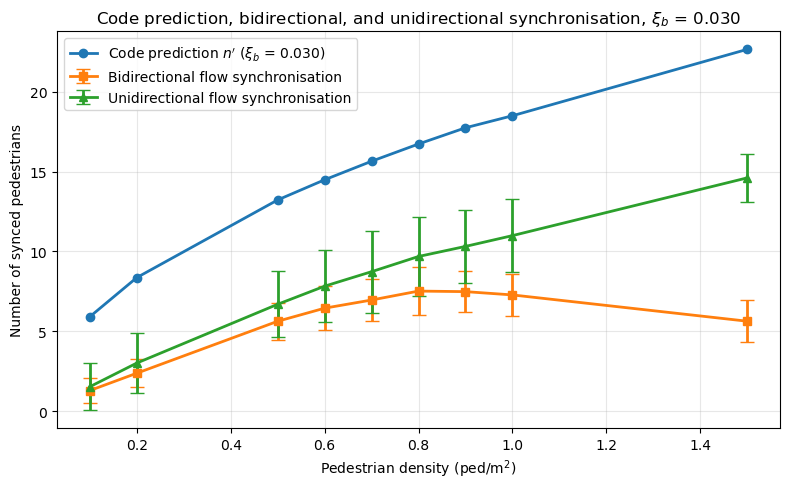

In [55]:
# ==================================================
# RE-PLOT SAME FIGURE BY ONLY CHANGING BRIDGE DAMPING
# Blue line = code prediction n'
# Orange = bidirectional synchronisation
# Green = unidirectional synchronisation
# ==================================================

import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# CHANGE ONLY THIS VALUE
# --------------------------------------------------
#xi_b = 0.005   # 0.5% damping
#xi_b = 0.010   # 1.0% damping
#xi_b = 0.020   # 2.0% damping
xi_b = 0.030   # 3.0% damping


# --------------------------------------------------
# Geometry
# --------------------------------------------------
Length = 50.0
Width = 2.0
S = Length * Width


# --------------------------------------------------
# Use same densities already loaded from old_df and new_df
# --------------------------------------------------
all_densities = np.unique(
    np.concatenate([
        old_df["actual_density"].to_numpy(dtype=float),
        new_df["actual_density"].to_numpy(dtype=float),
    ])
)

all_densities = np.sort(all_densities)

n_total = all_densities * S


# --------------------------------------------------
# Recalculate ONLY code prediction n'
# --------------------------------------------------
N_sync_code = np.zeros_like(all_densities, dtype=float)

for i, density in enumerate(all_densities):

    n = n_total[i]

    if density < 1.0:
        N_sync_code[i] = 10.8 * np.sqrt(xi_b * n)
    else:
        N_sync_code[i] = 1.85 * np.sqrt(n)


# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(8, 5))

# Blue: code prediction n'
plt.plot(
    all_densities,
    N_sync_code,
    marker="o",
    linewidth=2,
    color="tab:blue",
    label=fr"Code prediction $n'$ ($\xi_b$ = {xi_b:.3f})"
)

# Orange: bidirectional flow synchronisation
old_yerr = np.vstack([
    old_df["err_lower"].to_numpy(dtype=float),
    old_df["err_upper"].to_numpy(dtype=float)
])

plt.errorbar(
    old_df["actual_density"],
    old_df["mean_n_sync"],
    yerr=old_yerr,
    marker="s",
    linewidth=2,
    capsize=5,
    color="tab:orange",
    label="Bidirectional flow synchronisation"
)

# Green: unidirectional flow synchronisation
new_yerr = np.vstack([
    new_df["err_lower"].to_numpy(dtype=float),
    new_df["err_upper"].to_numpy(dtype=float)
])

plt.errorbar(
    new_df["actual_density"],
    new_df["mean_n_sync"],
    yerr=new_yerr,
    marker="^",
    linewidth=2,
    capsize=5,
    color="tab:green",
    label="Unidirectional flow synchronisation"
)

plt.xlabel("Pedestrian density (ped/m$^2$)")
plt.ylabel("Number of synced pedestrians")
plt.title(fr"Code prediction, bidirectional, and unidirectional synchronisation, $\xi_b$ = {xi_b:.3f}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()